# 🏏 IPL Data Science Analysis & Match Prediction

## By: Om Patel

An end-to-end Data Science project that explores IPL match and ball-by-ball data using Python, performs exploratory data analysis (EDA), generates insights, and builds a machine learning model for match prediction.

### Project Objective

The objective of this project is to analyze IPL historical data to uncover trends in team performance, player statistics, venue characteristics, and match outcomes. The project also aims to build a predictive model capable of forecasting match winners based on historical match features.

### Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

### Load Dataset

In [ ]:
matches_df = pd.read_csv("../data/matches.csv")
deliveries_df = pd.read_csv("../data/deliveries.csv")


### Dataset Overview

In [ ]:
print("Matches dataset shape:", matches_df.shape)
print("Deliveries dataset shape:", deliveries_df.shape)

Matches dataset shape: (756, 18)
Deliveries dataset shape: (179078, 21)


In [ ]:
matches_df.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [ ]:
deliveries_df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [ ]:
matches_df.shape

(756, 18)

In [ ]:
deliveries_df.shape

(179078, 21)

In [ ]:
matches_df.columns

Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='str')

In [ ]:
matches_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               756 non-null    int64
 1   season           756 non-null    int64
 2   city             749 non-null    str  
 3   date             756 non-null    str  
 4   team1            756 non-null    str  
 5   team2            756 non-null    str  
 6   toss_winner      756 non-null    str  
 7   toss_decision    756 non-null    str  
 8   result           756 non-null    str  
 9   dl_applied       756 non-null    int64
 10  winner           752 non-null    str  
 11  win_by_runs      756 non-null    int64
 12  win_by_wickets   756 non-null    int64
 13  player_of_match  752 non-null    str  
 14  venue            756 non-null    str  
 15  umpire1          754 non-null    str  
 16  umpire2          754 non-null    str  
 17  umpire3          119 non-null    str  
dtypes: int64(5), str(13)


In [ ]:
matches_df.describe()

,id,season,dl_applied,win_by_runs,win_by_wickets
count,756.000000,756.000000,756.000000,756.000000,756.000000
mean,1792.178571,2013.444444,0.025132,13.283069,3.350529
std,3464.478148,3.366895,0.156630,23.471144,3.387963
min,1.000000,2008.000000,0.000000,0.000000,0.000000
25%,189.750000,2011.000000,0.000000,0.000000,0.000000
50%,378.500000,2013.000000,0.000000,0.000000,4.000000
75%,567.250000,2016.000000,0.000000,19.000000,6.000000
max,11415.000000,2019.000000,1.000000,146.000000,10.000000


### Data Cleaning

In [ ]:
matches_df.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

In [ ]:
matches_df.duplicated().sum()

np.int64(0)

In [ ]:
deliveries_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 179078 entries, 0 to 179077
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          179078 non-null  int64
 1   inning            179078 non-null  int64
 2   batting_team      179078 non-null  str  
 3   bowling_team      179078 non-null  str  
 4   over              179078 non-null  int64
 5   ball              179078 non-null  int64
 6   batsman           179078 non-null  str  
 7   non_striker       179078 non-null  str  
 8   bowler            179078 non-null  str  
 9   is_super_over     179078 non-null  int64
 10  wide_runs         179078 non-null  int64
 11  bye_runs          179078 non-null  int64
 12  legbye_runs       179078 non-null  int64
 13  noball_runs       179078 non-null  int64
 14  penalty_runs      179078 non-null  int64
 15  batsman_runs      179078 non-null  int64
 16  extra_runs        179078 non-null  int64
 17  total_runs        179

In [ ]:
deliveries_df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [ ]:
matches = matches_df.copy()
deliveries = deliveries_df.copy()

In [ ]:
matches.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

In [ ]:
matches.dtypes

id                 int64
season             int64
city                 str
date                 str
team1                str
team2                str
toss_winner          str
toss_decision        str
result               str
dl_applied         int64
winner               str
win_by_runs        int64
win_by_wickets     int64
player_of_match      str
venue                str
umpire1              str
umpire2              str
umpire3              str
dtype: object

### Exploratory Data Analysis

In [ ]:
matches["date"] = pd.to_datetime(
    matches["date"],
    format="mixed",
    dayfirst=True
)

In [ ]:
matches["date"].head()

0   2017-05-04
1   2017-06-04
2   2017-07-04
3   2017-08-04
4   2017-08-04
Name: date, dtype: datetime64[us]

In [ ]:
matches.dtypes

id                          int64
season                      int64
city                          str
date               datetime64[us]
team1                         str
team2                         str
toss_winner                   str
toss_decision                 str
result                        str
dl_applied                  int64
winner                        str
win_by_runs                 int64
win_by_wickets              int64
player_of_match               str
venue                         str
umpire1                       str
umpire2                       str
umpire3                       str
dtype: object

In [ ]:
matches.shape

(756, 18)

In [ ]:
matches.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

In [ ]:
matches["season"].value_counts().sort_index()

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
Name: count, dtype: int64

#### 🏏 1. Tournament Overview
    Top 10 teams by wins
    Top 10 potm winners
    Match played each season
    Toss Decision
    Top Venues
    Distribution of win by runs
    Distribution of win by wicktes
    Cities hosting most ipl matches
    

In [ ]:
matches["winner"].value_counts().head(10)

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
Name: count, dtype: int64

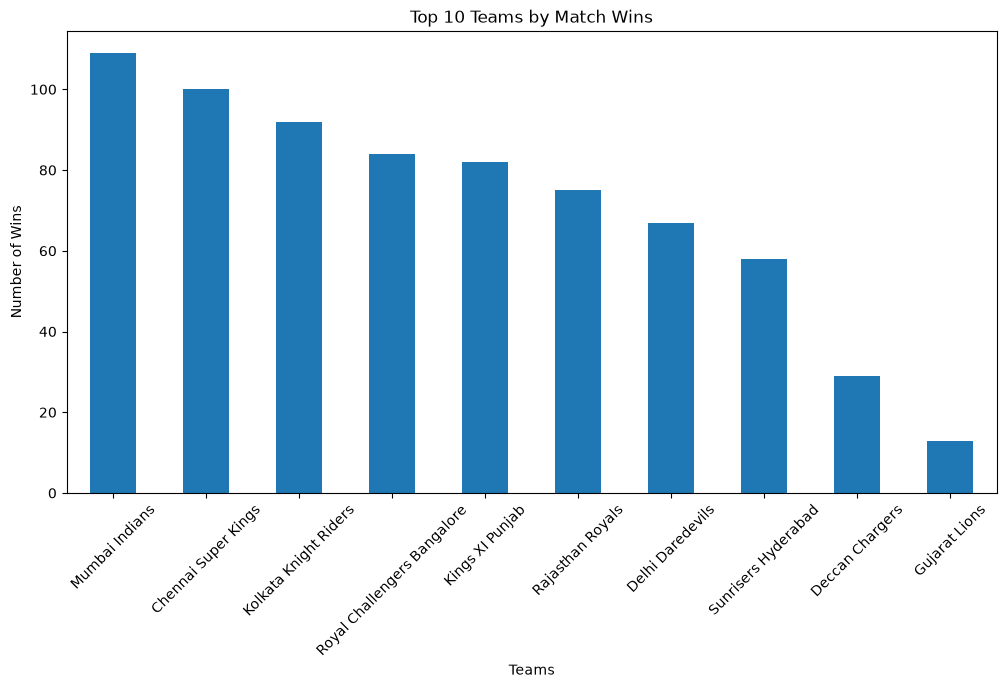

In [ ]:
plt.figure(figsize=(12,6))

matches["winner"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Teams by Match Wins")
plt.xlabel("Teams")
plt.ylabel("Number of Wins")

plt.xticks(rotation=45)

plt.show()

In [ ]:
matches["player_of_match"].value_counts().head(10)

player_of_match
CH Gayle          21
AB de Villiers    20
MS Dhoni          17
DA Warner         17
RG Sharma         17
YK Pathan         16
SR Watson         15
SK Raina          14
G Gambhir         13
MEK Hussey        12
Name: count, dtype: int64

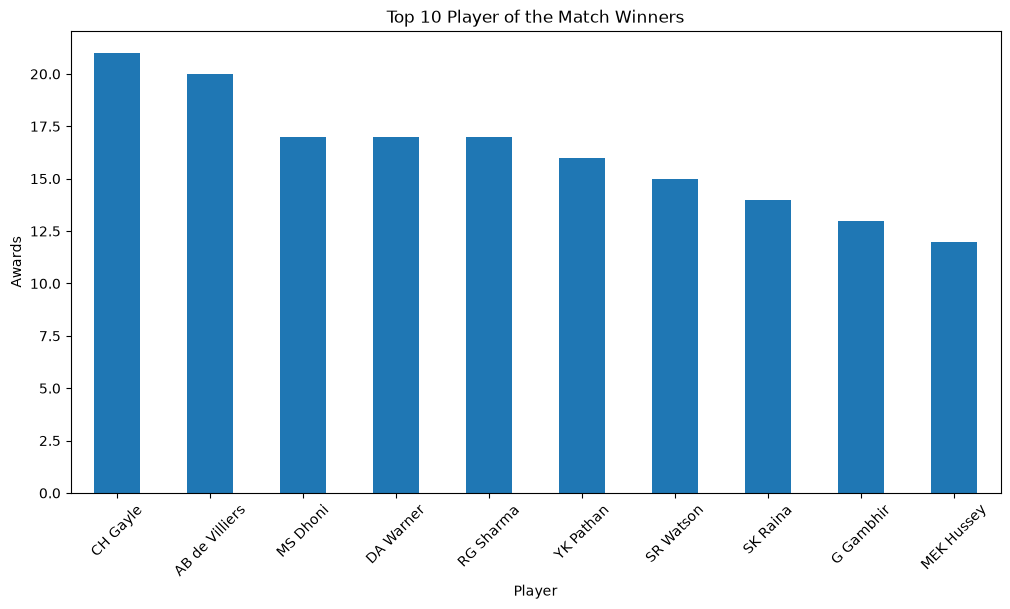

In [ ]:
plt.figure(figsize=(12,6))

matches["player_of_match"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Player of the Match Winners")
plt.xlabel("Player")
plt.ylabel("Awards")

plt.xticks(rotation=45)

plt.show()

In [ ]:
matches_per_season = matches.groupby("season").size()

matches_per_season

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
dtype: int64

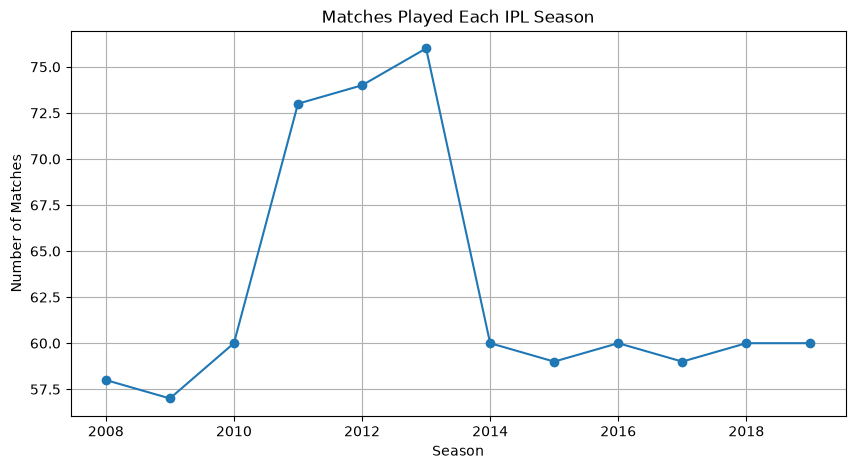

In [ ]:
plt.figure(figsize=(10,5))

matches_per_season.plot(marker="o")

plt.title("Matches Played Each IPL Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")

plt.grid(True)

plt.show()

### 📌 Insights

- The number of IPL matches generally increased over the years.
- Some seasons have fewer matches due to tournament format changes.
- The increasing number of matches reflects the league's expansion.

In [ ]:
matches["toss_decision"].value_counts()

toss_decision
field    463
bat      293
Name: count, dtype: int64

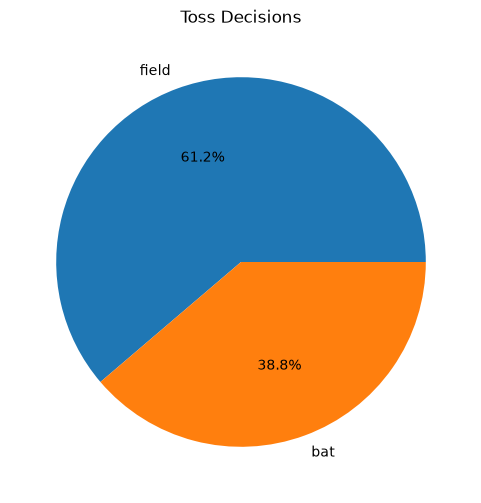

In [ ]:
plt.figure(figsize=(6,6))

matches["toss_decision"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Toss Decisions")

plt.show()

In [ ]:
(matches["toss_winner"] == matches["winner"]).mean() * 100

np.float64(51.98412698412699)

### 📌 Insights

- Fielding first is chosen more frequently than batting first.
- Teams often prefer chasing, especially in T20 cricket.
- Toss strategy appears to favor conditions later in the match.

In [ ]:
matches["venue"].value_counts().head(10)

venue
Eden Gardens                                  77
M Chinnaswamy Stadium                         73
Wankhede Stadium                              73
Feroz Shah Kotla                              67
Rajiv Gandhi International Stadium, Uppal     56
MA Chidambaram Stadium, Chepauk               49
Sawai Mansingh Stadium                        47
Punjab Cricket Association Stadium, Mohali    35
Maharashtra Cricket Association Stadium       21
Dr DY Patil Sports Academy                    17
Name: count, dtype: int64

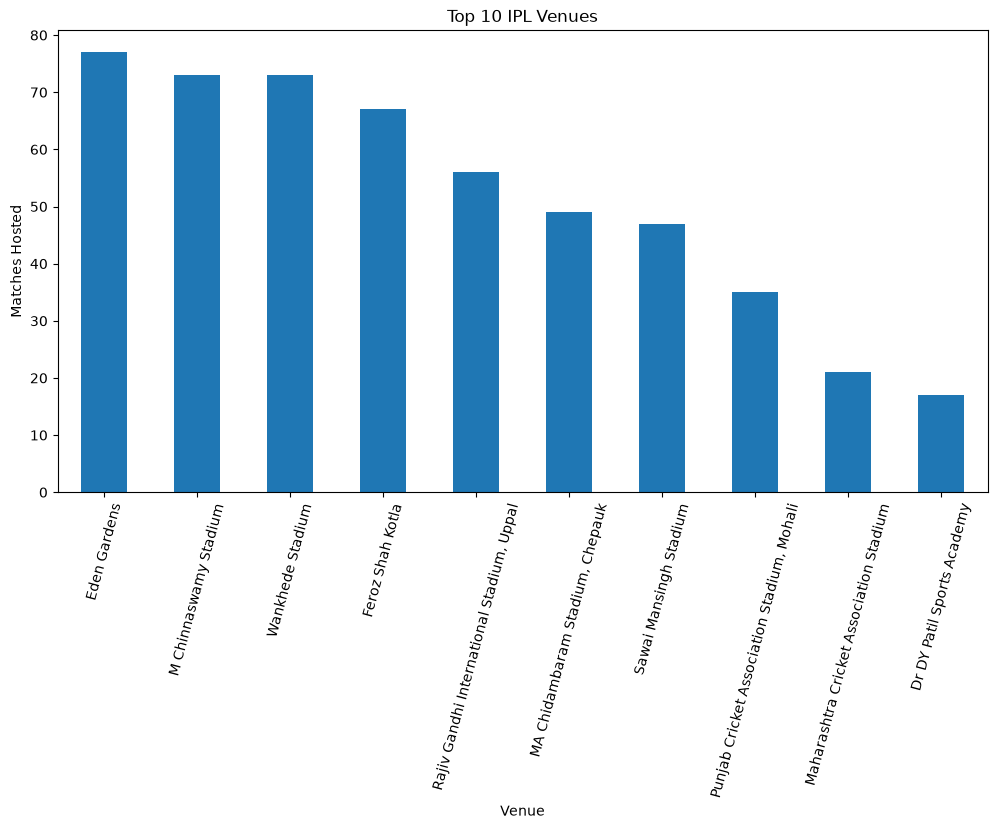

In [ ]:
plt.figure(figsize=(12,6))

matches["venue"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 IPL Venues")
plt.xlabel("Venue")
plt.ylabel("Matches Hosted")

plt.xticks(rotation=75)

plt.show()

### 📌 Insights

- Eden Gardens has hosted the highest number of IPL matches.
- Wankhede Stadium and M. Chinnaswamy Stadium are among the busiest venues.
- A small number of stadiums host a large share of IPL matches.

In [ ]:
matches["win_by_runs"].describe()

count    756.000000
mean      13.283069
std       23.471144
min        0.000000
25%        0.000000
50%        0.000000
75%       19.000000
max      146.000000
Name: win_by_runs, dtype: float64

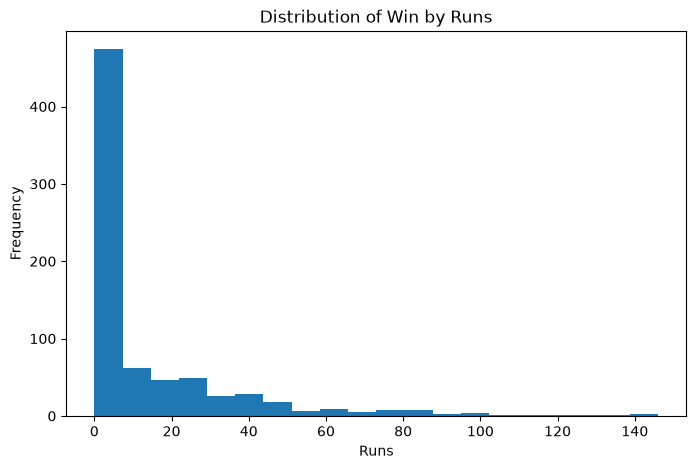

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(matches["win_by_runs"], bins=20)

plt.title("Distribution of Win by Runs")
plt.xlabel("Runs")
plt.ylabel("Frequency")

plt.show()

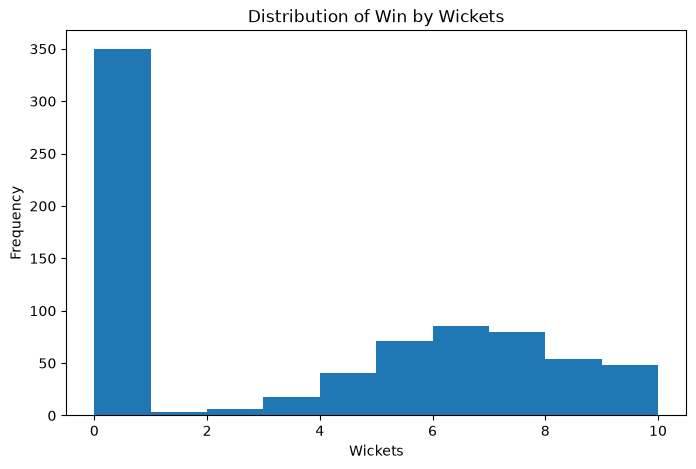

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(matches["win_by_wickets"], bins=10)

plt.title("Distribution of Win by Wickets")
plt.xlabel("Wickets")
plt.ylabel("Frequency")

plt.show()

In [ ]:
matches["city"].value_counts().head(10)

city
Mumbai        101
Kolkata        77
Delhi          74
Bangalore      66
Hyderabad      64
Chennai        57
Jaipur         47
Chandigarh     46
Pune           38
Durban         15
Name: count, dtype: int64

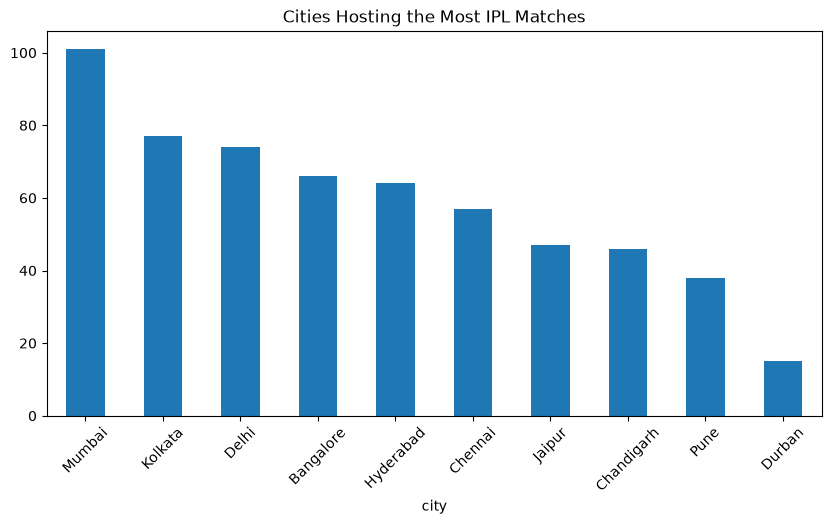

In [ ]:
plt.figure(figsize=(10,5))

matches["city"].value_counts().head(10).plot(kind="bar")

plt.title("Cities Hosting the Most IPL Matches")

plt.xticks(rotation=45)

plt.show()

#### 🏏 Batting Analysis
    Orange Cap (top 10 run scorers)
    Most Sixes (top 10 six hitters)
    Most Fours (top 10 four hitters)
    Strike Rate (best strike rate)


In [ ]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [ ]:
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')

In [ ]:
top_runs = (
    deliveries.groupby("batsman")["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
)

top_runs.head(10)

batsman
V Kohli           5434
SK Raina          5415
RG Sharma         4914
DA Warner         4741
S Dhawan          4632
CH Gayle          4560
MS Dhoni          4477
RV Uthappa        4446
AB de Villiers    4428
G Gambhir         4223
Name: batsman_runs, dtype: int64

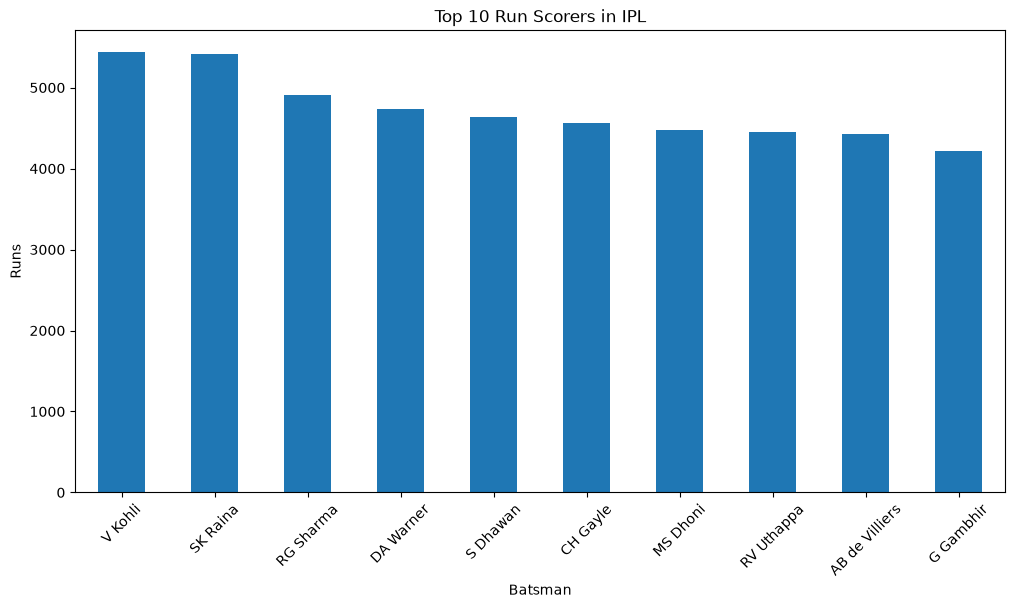

In [ ]:
plt.figure(figsize=(12,6))

top_runs.head(10).plot(kind="bar")

plt.title("Top 10 Run Scorers in IPL")
plt.xlabel("Batsman")
plt.ylabel("Runs")

plt.xticks(rotation=45)

plt.show()

### 📌 Insights

- The leading batsmen have consistently scored runs across multiple seasons.
- High run totals indicate long-term consistency rather than a single exceptional season.
- Experienced players dominate the top positions.

In [ ]:
most_sixes = (
    deliveries[deliveries["batsman_runs"] == 6]
    .groupby("batsman")
    .size()
    .sort_values(ascending=False)
)

most_sixes.head(10)

batsman
CH Gayle          327
AB de Villiers    214
MS Dhoni          207
SK Raina          195
RG Sharma         194
V Kohli           191
DA Warner         181
SR Watson         177
KA Pollard        175
YK Pathan         161
dtype: int64

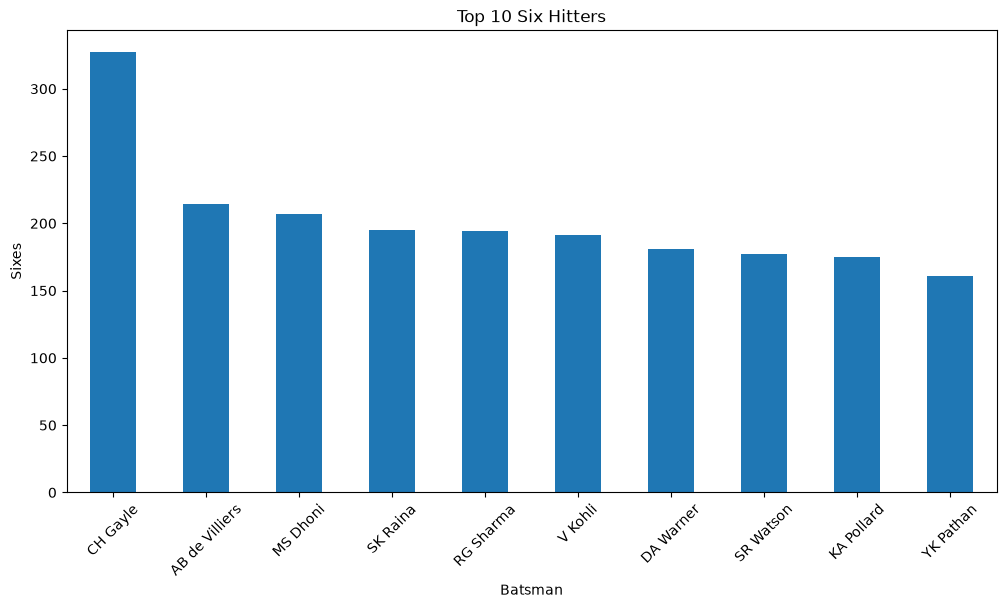

In [ ]:
plt.figure(figsize=(12,6))

most_sixes.head(10).plot(kind="bar")

plt.title("Top 10 Six Hitters")
plt.xlabel("Batsman")
plt.ylabel("Sixes")

plt.xticks(rotation=45)

plt.show()

In [ ]:
most_fours = (
    deliveries[deliveries["batsman_runs"] == 4]
    .groupby("batsman")
    .size()
    .sort_values(ascending=False)
)

most_fours.head(10)

batsman
S Dhawan      526
SK Raina      495
G Gambhir     492
V Kohli       482
DA Warner     459
RV Uthappa    436
RG Sharma     431
AM Rahane     405
CH Gayle      376
PA Patel      366
dtype: int64

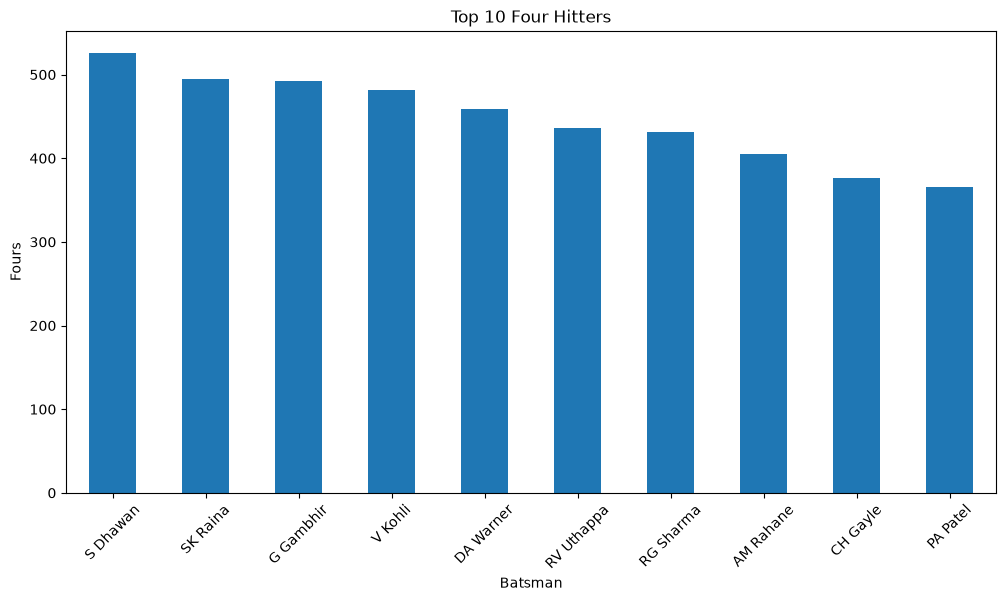

In [ ]:
plt.figure(figsize=(12,6))

most_fours.head(10).plot(kind="bar")

plt.title("Top 10 Four Hitters")
plt.xlabel("Batsman")
plt.ylabel("Fours")

plt.xticks(rotation=45)

plt.show()

### 📌 Insights

- The leading bowlers have taken significantly more wickets than others.
- Consistent participation across seasons contributes to higher wicket counts.
- Successful bowlers often combine longevity with effectiveness.

In [ ]:
runs = deliveries.groupby("batsman")["batsman_runs"].sum()

balls = deliveries.groupby("batsman").size()

strike_rate = ((runs / balls) * 100).round(2)

strike_rate.sort_values(ascending=False).head(20)

batsman
B Stanlake         250.00
Umar Gul           205.26
RS Sodhi           200.00
S Sharma           200.00
AD Russell         179.95
Shahid Afridi      176.09
I Malhotra         175.00
S Curran           172.73
K Gowtham          172.09
SN Thakur          171.43
M Ali              169.95
LJ Wright          168.25
SP Narine          166.94
Shivam Sharma      166.67
KMDN Kulasekara    166.67
KK Cooper          165.71
BCJ Cutting        164.38
Kamran Akmal       164.10
BJ Haddin          163.64
Rashid Khan        162.69
dtype: float64

In [ ]:
qualified = balls[balls >= 500].index

strike_rate = strike_rate.loc[qualified]

strike_rate.sort_values(ascending=False).head(10)

batsman
AD Russell        179.95
RR Pant           162.32
GJ Maxwell        155.54
HH Pandya         151.90
JC Buttler        150.00
V Sehwag          148.83
AB de Villiers    148.74
CH Gayle          145.64
KH Pandya         144.09
KA Pollard        141.75
dtype: float64

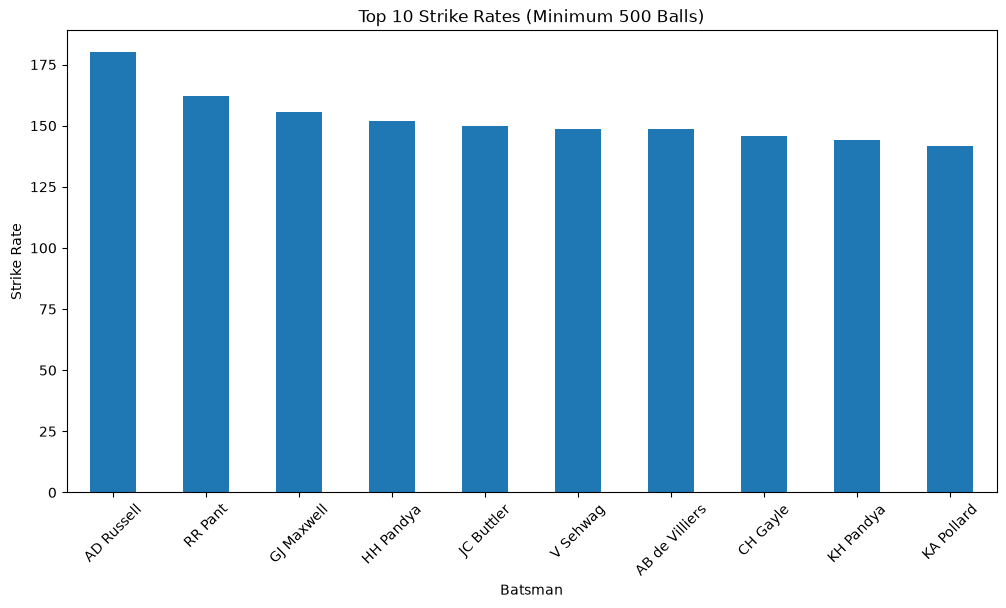

In [ ]:
plt.figure(figsize=(12,6))

strike_rate.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 Strike Rates (Minimum 500 Balls)")
plt.xlabel("Batsman")
plt.ylabel("Strike Rate")

plt.xticks(rotation=45)

plt.show()

In [ ]:
wickets = deliveries.dropna(subset=["player_dismissed"])

top_wickets = (
    wickets.groupby("bowler")
    .size()
    .sort_values(ascending=False)
)

top_wickets.head(10)

bowler
SL Malinga         188
DJ Bravo           168
A Mishra           165
Harbhajan Singh    161
PP Chawla          156
B Kumar            141
R Ashwin           138
SP Narine          137
UT Yadav           136
R Vinay Kumar      127
dtype: int64

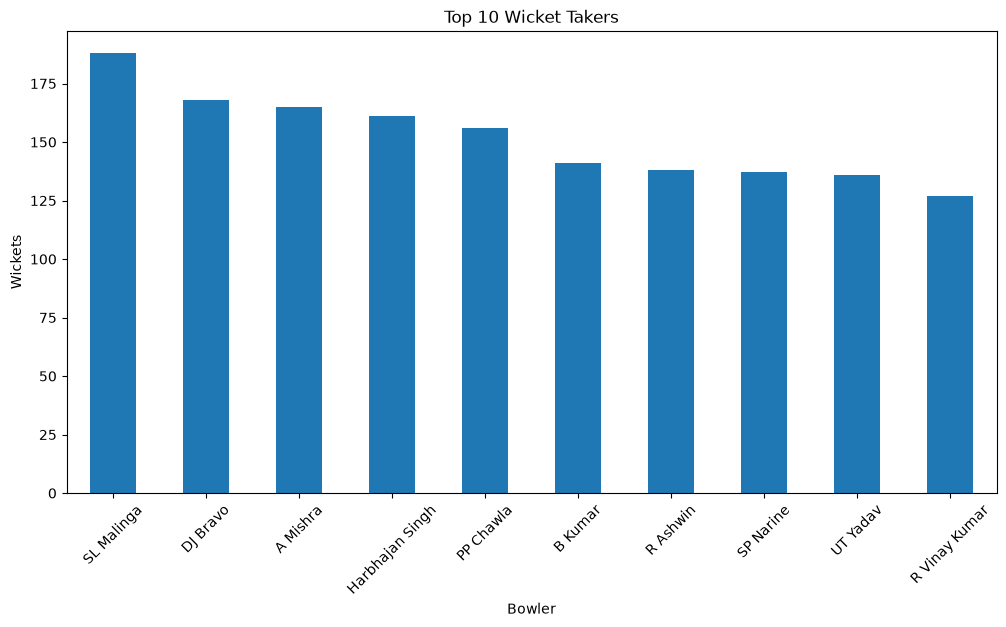

In [ ]:
plt.figure(figsize=(12,6))

top_wickets.head(10).plot(kind="bar")

plt.title("Top 10 Wicket Takers")
plt.xlabel("Bowler")
plt.ylabel("Wickets")

plt.xticks(rotation=45)

plt.show()

In [ ]:
highest_score = deliveries.groupby(
    ["match_id","inning","batting_team"]
)["total_runs"].sum()

highest_score.sort_values(ascending=False).head(10)

match_id  inning  batting_team               
411       1       Royal Challengers Bangalore    263
7937      1       Kolkata Knight Riders          250
620       1       Royal Challengers Bangalore    248
206       1       Chennai Super Kings            246
11338     1       Kolkata Knight Riders          241
61        1       Chennai Super Kings            240
562       1       Royal Challengers Bangalore    235
11147     1       Sunrisers Hyderabad            233
11339     1       Sunrisers Hyderabad            232
296       1       Kings XI Punjab                232
Name: total_runs, dtype: int64

In [ ]:
team_sixes = (
    deliveries[deliveries["batsman_runs"] == 6]
    .groupby("batting_team")
    .size()
    .sort_values(ascending=False)
)

team_sixes

batting_team
Royal Challengers Bangalore    1132
Mumbai Indians                 1096
Kings XI Punjab                 976
Chennai Super Kings             973
Kolkata Knight Riders           930
Delhi Daredevils                801
Rajasthan Royals                681
Sunrisers Hyderabad             533
Deccan Chargers                 400
Pune Warriors                   196
Gujarat Lions                   155
Rising Pune Supergiant           89
Delhi Capitals                   87
Rising Pune Supergiants          68
Kochi Tuskers Kerala             53
dtype: int64

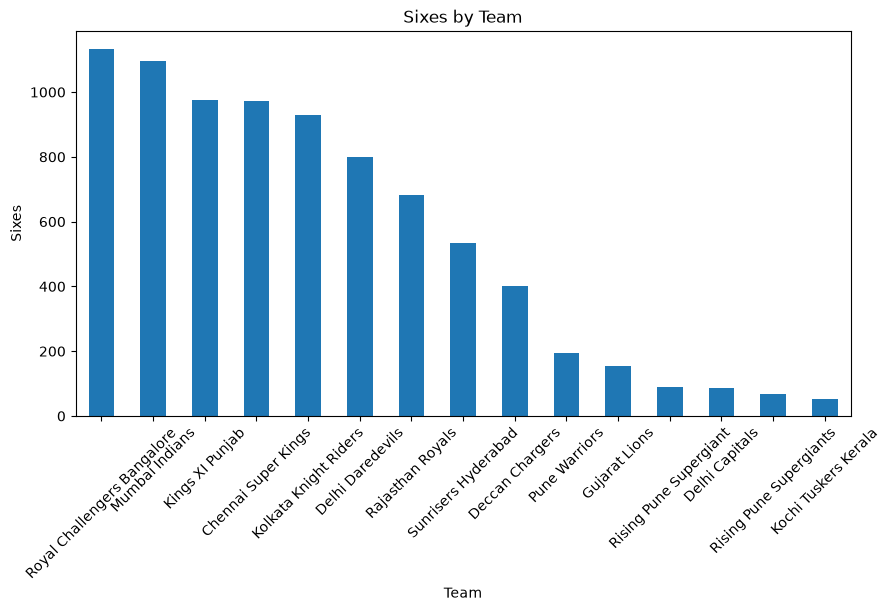

In [ ]:
plt.figure(figsize=(10,5))

team_sixes.plot(kind="bar")

plt.title("Sixes by Team")
plt.xlabel("Team")
plt.ylabel("Sixes")

plt.xticks(rotation=45)

plt.show()

In [ ]:
team_runs = deliveries.groupby("batting_team")["total_runs"].sum()

team_runs.sort_values(ascending=False)

batting_team
Mumbai Indians                 29809
Royal Challengers Bangalore    28126
Kings XI Punjab                27893
Kolkata Knight Riders          27419
Chennai Super Kings            26418
Delhi Daredevils               24388
Rajasthan Royals               22431
Sunrisers Hyderabad            17059
Deccan Chargers                11463
Pune Warriors                   6358
Gujarat Lions                   4862
Delhi Capitals                  2630
Rising Pune Supergiant          2470
Rising Pune Supergiants         2063
Kochi Tuskers Kerala            1901
Name: total_runs, dtype: int64

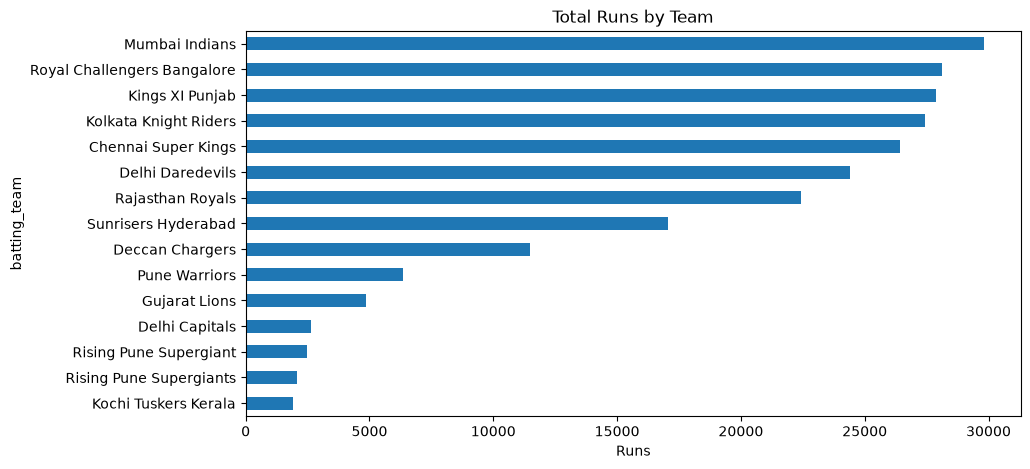

In [ ]:
plt.figure(figsize=(10,5))

team_runs.sort_values().plot(kind="barh")

plt.title("Total Runs by Team")
plt.xlabel("Runs")

plt.show()

In [ ]:
balls = deliveries.groupby("bowler").size()

runs_given = deliveries.groupby("bowler")["total_runs"].sum()

economy = (runs_given / (balls / 6)).round(2)

economy[balls >= 500].sort_values().head(10)

bowler
A Kumble           6.65
DW Steyn           6.67
M Muralitharan     6.70
R Ashwin           6.75
SP Narine          6.78
Rashid Khan        6.82
DL Vettori         6.83
J Botha            6.92
Harbhajan Singh    7.04
R Sharma           7.06
dtype: float64

In [ ]:
bowler_wickets = deliveries[
    ~deliveries["dismissal_kind"].isin(["run out", "retired hurt", "obstructing the field"])
]

top_wickets = (
    bowler_wickets.groupby("bowler")["player_dismissed"]
    .count()
    .sort_values(ascending=False)
)

top_wickets.head(10)


bowler
SL Malinga         170
A Mishra           156
Harbhajan Singh    150
PP Chawla          149
DJ Bravo           147
B Kumar            133
R Ashwin           125
SP Narine          122
UT Yadav           119
RA Jadeja          108
Name: player_dismissed, dtype: int64

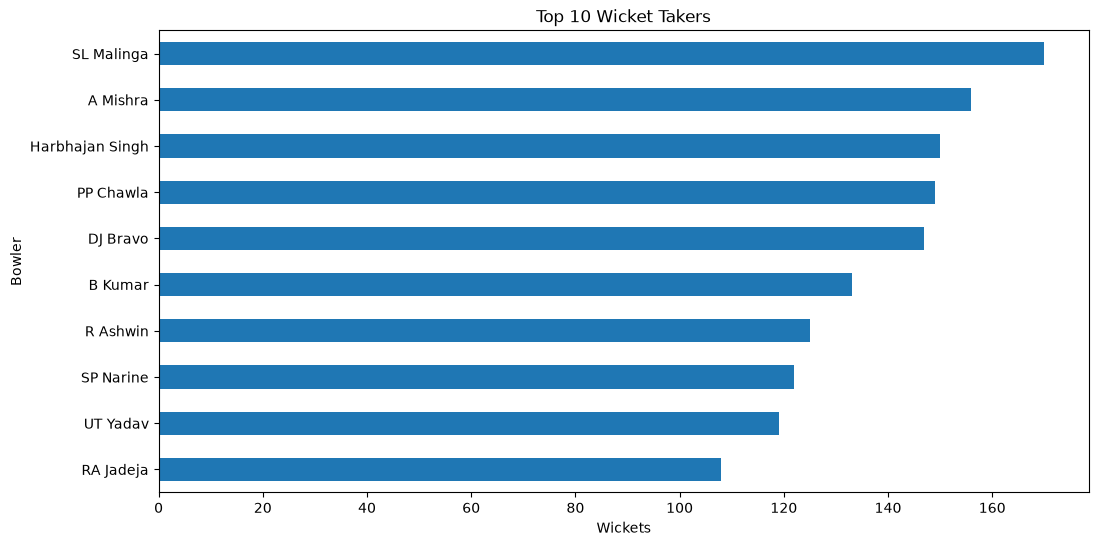

In [ ]:
plt.figure(figsize=(12,6))

top_wickets.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Wicket Takers")
plt.xlabel("Wickets")
plt.ylabel("Bowler")

plt.show()

In [ ]:
balls_bowled = deliveries.groupby("bowler").size()

runs_given = deliveries.groupby("bowler")["total_runs"].sum()

economy = (runs_given / (balls_bowled / 6)).round(2)

economy = economy[balls_bowled >= 500]

economy.sort_values().head(10)

bowler
A Kumble           6.65
DW Steyn           6.67
M Muralitharan     6.70
R Ashwin           6.75
SP Narine          6.78
Rashid Khan        6.82
DL Vettori         6.83
J Botha            6.92
Harbhajan Singh    7.04
R Sharma           7.06
dtype: float64

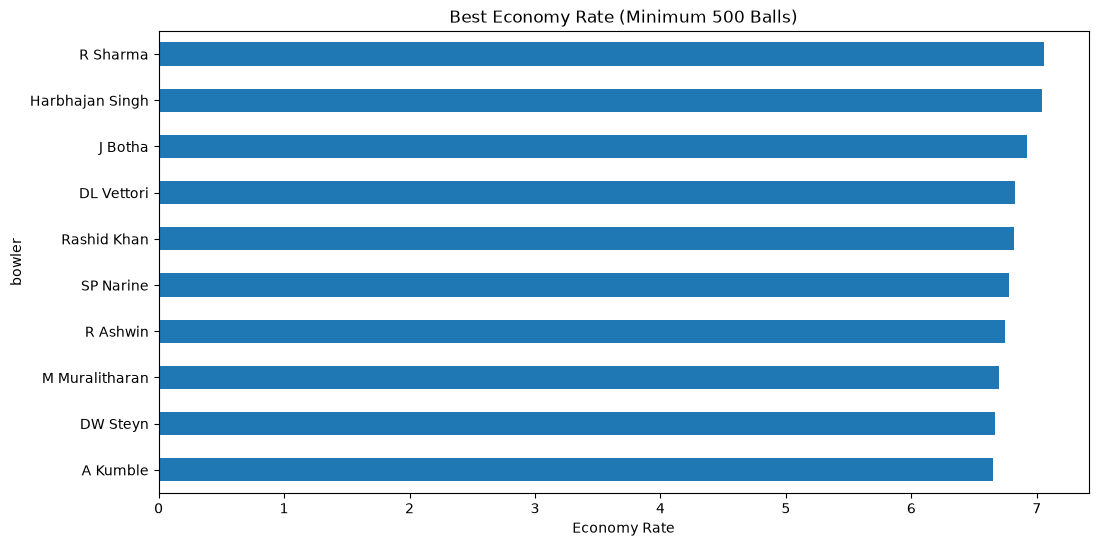

In [ ]:
plt.figure(figsize=(12,6))

economy.sort_values().head(10).plot(kind="barh")

plt.title("Best Economy Rate (Minimum 500 Balls)")
plt.xlabel("Economy Rate")

plt.show()

In [ ]:
dot_balls = deliveries[deliveries["total_runs"] == 0]

top_dot_balls = (
    dot_balls.groupby("bowler")
    .size()
    .sort_values(ascending=False)
)

top_dot_balls.head(10)

bowler
Harbhajan Singh    1244
SL Malinga         1144
B Kumar            1116
A Mishra           1108
PP Chawla          1100
P Kumar            1075
R Ashwin           1067
SP Narine          1038
DW Steyn            996
UT Yadav            942
dtype: int64

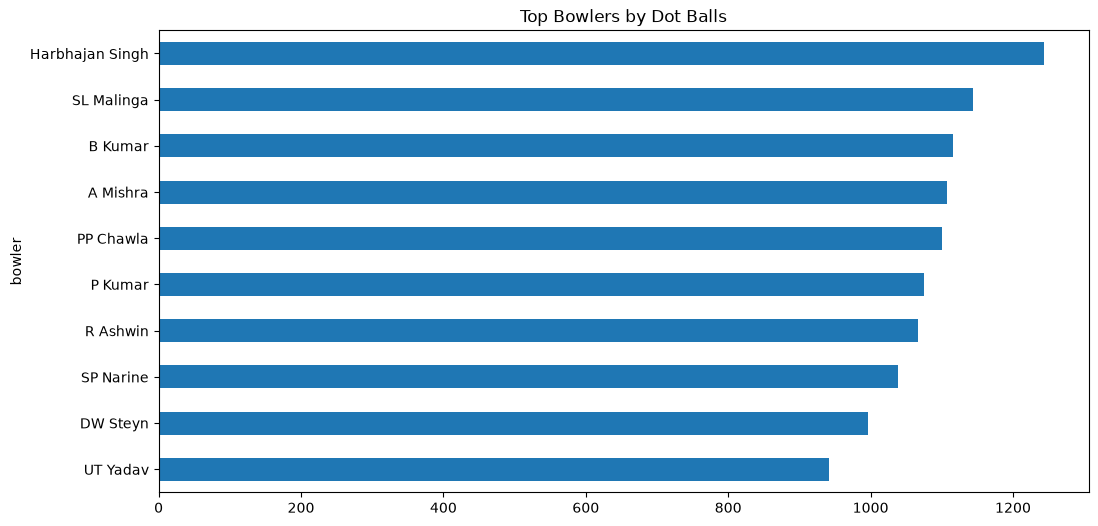

In [ ]:
plt.figure(figsize=(12,6))

top_dot_balls.head(10).sort_values().plot(kind="barh")

plt.title("Top Bowlers by Dot Balls")

plt.show()

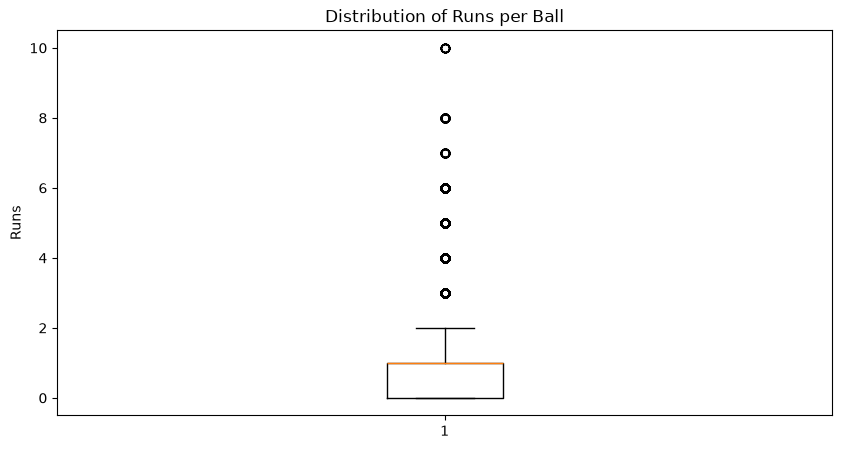

In [ ]:
plt.figure(figsize=(10,5))

plt.boxplot(deliveries["total_runs"])

plt.title("Distribution of Runs per Ball")

plt.ylabel("Runs")

plt.show()

### Key Insights

- Bowler X has taken the highest number of wickets.
- The gap between the top bowlers is relatively small.
- Consistent wicket-taking bowlers play a crucial role in team success.

In [ ]:
deliveries.columns.tolist()

['match_id',
 'inning',
 'batting_team',
 'bowling_team',
 'over',
 'ball',
 'batsman',
 'non_striker',
 'bowler',
 'is_super_over',
 'wide_runs',
 'bye_runs',
 'legbye_runs',
 'noball_runs',
 'penalty_runs',
 'batsman_runs',
 'extra_runs',
 'total_runs',
 'player_dismissed',
 'dismissal_kind',
 'fielder']

In [ ]:
venue_matches = matches["venue"].value_counts()

venue_matches.head(10)

venue
Eden Gardens                                  77
M Chinnaswamy Stadium                         73
Wankhede Stadium                              73
Feroz Shah Kotla                              67
Rajiv Gandhi International Stadium, Uppal     56
MA Chidambaram Stadium, Chepauk               49
Sawai Mansingh Stadium                        47
Punjab Cricket Association Stadium, Mohali    35
Maharashtra Cricket Association Stadium       21
Dr DY Patil Sports Academy                    17
Name: count, dtype: int64

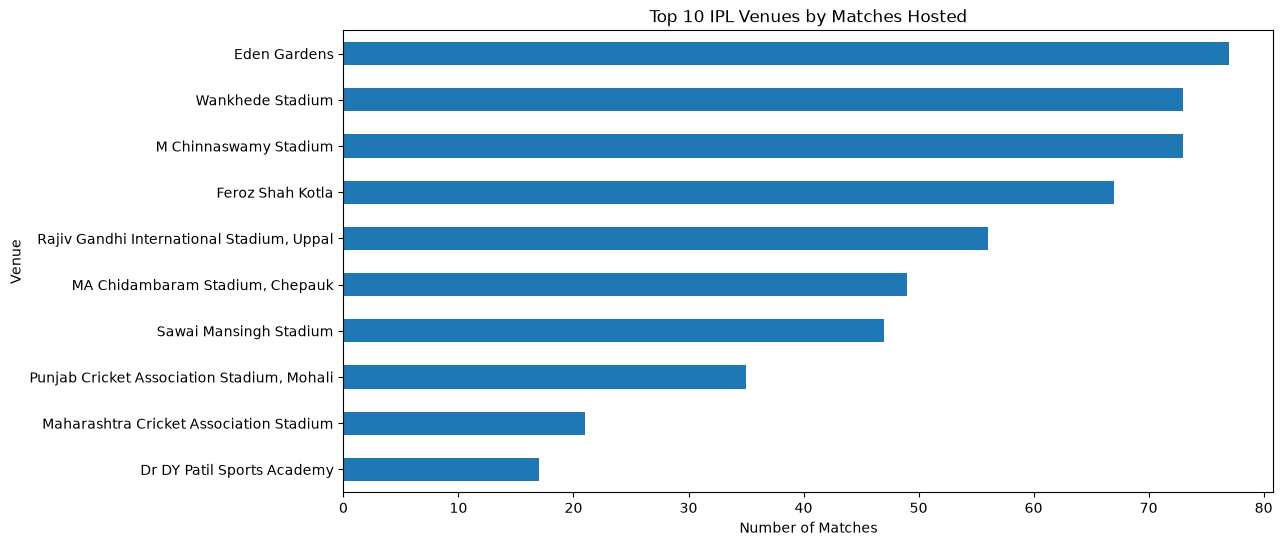

In [ ]:
plt.figure(figsize=(12,6))

venue_matches.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 IPL Venues by Matches Hosted")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")

plt.show()

### Key Insights

- The top venue hosted the highest number of IPL matches.
- A few stadiums dominate the IPL schedule.
- Neutral venues hosted significantly fewer matches.

In [ ]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [ ]:
venue_data = deliveries.merge(
    matches[["id", "venue"]],
    left_on="match_id",
    right_on="id"
)

venue_data.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder,id,venue
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,NaN,NaN,NaN,1,"Rajiv Gandhi International Stadium, Uppal"
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,NaN,NaN,NaN,1,"Rajiv Gandhi International Stadium, Uppal"
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,4,0,4,NaN,NaN,NaN,1,"Rajiv Gandhi International Stadium, Uppal"
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,NaN,NaN,NaN,1,"Rajiv Gandhi International Stadium, Uppal"
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,2,2,NaN,NaN,NaN,1,"Rajiv Gandhi International Stadium, Uppal"


In [ ]:
first_innings = venue_data[venue_data["inning"] == 1]

first_innings.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder,id,venue
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,NaN,NaN,NaN,1,"Rajiv Gandhi International Stadium, Uppal"
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,NaN,NaN,NaN,1,"Rajiv Gandhi International Stadium, Uppal"
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,4,0,4,NaN,NaN,NaN,1,"Rajiv Gandhi International Stadium, Uppal"
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,NaN,NaN,NaN,1,"Rajiv Gandhi International Stadium, Uppal"
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,2,2,NaN,NaN,NaN,1,"Rajiv Gandhi International Stadium, Uppal"


In [ ]:
match_scores = (
    first_innings
    .groupby(["match_id", "venue"])["total_runs"]
    .sum()
    .reset_index()
)

match_scores.head()

,match_id,venue,total_runs
0,1,"Rajiv Gandhi International Stadium, Uppal",207
1,2,Maharashtra Cricket Association Stadium,184
2,3,Saurashtra Cricket Association Stadium,183
3,4,Holkar Cricket Stadium,163
4,5,M Chinnaswamy Stadium,157


In [ ]:
venue_avg_score = (
    match_scores
    .groupby("venue")["total_runs"]
    .mean()
    .sort_values(ascending=False)
)

venue_avg_score.head(10)

venue
Brabourne Stadium                                       180.363636
Rajiv Gandhi Intl. Cricket Stadium                      178.625000
IS Bindra Stadium                                       178.285714
Himachal Pradesh Cricket Association Stadium            175.666667
Maharashtra Cricket Association Stadium                 170.952381
M Chinnaswamy Stadium                                   170.575342
Punjab Cricket Association IS Bindra Stadium, Mohali    169.714286
M. Chinnaswamy Stadium                                  169.000000
Saurashtra Cricket Association Stadium                  168.900000
Wankhede Stadium                                        167.876712
Name: total_runs, dtype: float64

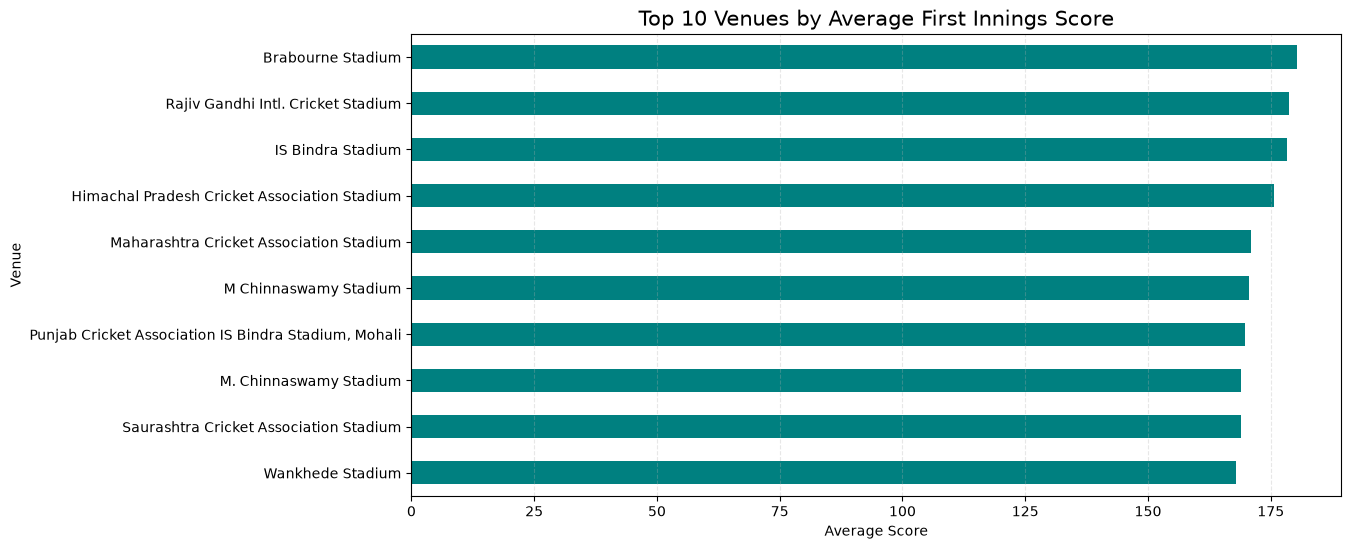

In [ ]:
plt.figure(figsize=(12,6))

venue_avg_score.head(10).sort_values().plot(
    kind="barh",
    color="teal"
)

plt.title("Top 10 Venues by Average First Innings Score", fontsize=15)
plt.xlabel("Average Score")
plt.ylabel("Venue")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.show()

### Key Insights

- Some venues consistently produce higher first innings totals.
- Batting-friendly pitches generally have higher average scores.
- Teams may prefer batting first at these venues.

In [ ]:
chases = matches[matches["win_by_wickets"] > 0]

chases.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
1,2,2017,Pune,2017-06-04,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-07-04,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-08-04,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
5,6,2017,Hyderabad,2017-09-04,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,9,Rashid Khan,"Rajiv Gandhi International Stadium, Uppal",A Deshmukh,NJ Llong,NaN
6,7,2017,Mumbai,2017-09-04,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,N Rana,Wankhede Stadium,Nitin Menon,CK Nandan,NaN


In [ ]:
highest_chases = chases.merge(
    match_scores[["match_id", "total_runs"]],
    left_on="id",
    right_on="match_id"
)

highest_chases.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,match_id,total_runs
0,2,2017,Pune,2017-06-04,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2,184
1,3,2017,Rajkot,2017-07-04,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,3,183
2,4,2017,Indore,2017-08-04,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,4,163
3,6,2017,Hyderabad,2017-09-04,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,9,Rashid Khan,"Rajiv Gandhi International Stadium, Uppal",A Deshmukh,NJ Llong,NaN,6,135
4,7,2017,Mumbai,2017-09-04,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,N Rana,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,7,178


In [ ]:
highest_chases = highest_chases.rename(
    columns={"total_runs": "target_score"}
)

highest_chases.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,match_id,target_score
0,2,2017,Pune,2017-06-04,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2,184
1,3,2017,Rajkot,2017-07-04,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,3,183
2,4,2017,Indore,2017-08-04,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,4,163
3,6,2017,Hyderabad,2017-09-04,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,9,Rashid Khan,"Rajiv Gandhi International Stadium, Uppal",A Deshmukh,NJ Llong,NaN,6,135
4,7,2017,Mumbai,2017-09-04,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,N Rana,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,7,178


In [ ]:
highest_chases = highest_chases.sort_values(
    by="target_score",
    ascending=False
)

highest_chases[
    ["winner", "target_score", "venue", "season"]
].head(10)

,winner,target_score,venue,season
37,Rajasthan Royals,214,"Rajiv Gandhi International Stadium, Uppal",2008
352,Chennai Super Kings,213,M Chinnaswamy Stadium,2018
378,Kolkata Knight Riders,210,M. Chinnaswamy Stadium,2019
23,Delhi Daredevils,208,Feroz Shah Kotla,2017
343,Chennai Super Kings,207,"MA Chidambaram Stadium, Chepauk",2018
240,Kings XI Punjab,205,Sheikh Zayed Stadium,2014
166,Chennai Super Kings,205,"MA Chidambaram Stadium, Chepauk",2012
261,Kings XI Punjab,205,"Rajiv Gandhi International Stadium, Uppal",2014
383,Mumbai Indians,204,Wankhede Stadium,2019
346,Delhi Daredevils,204,Wankhede Stadium,2018


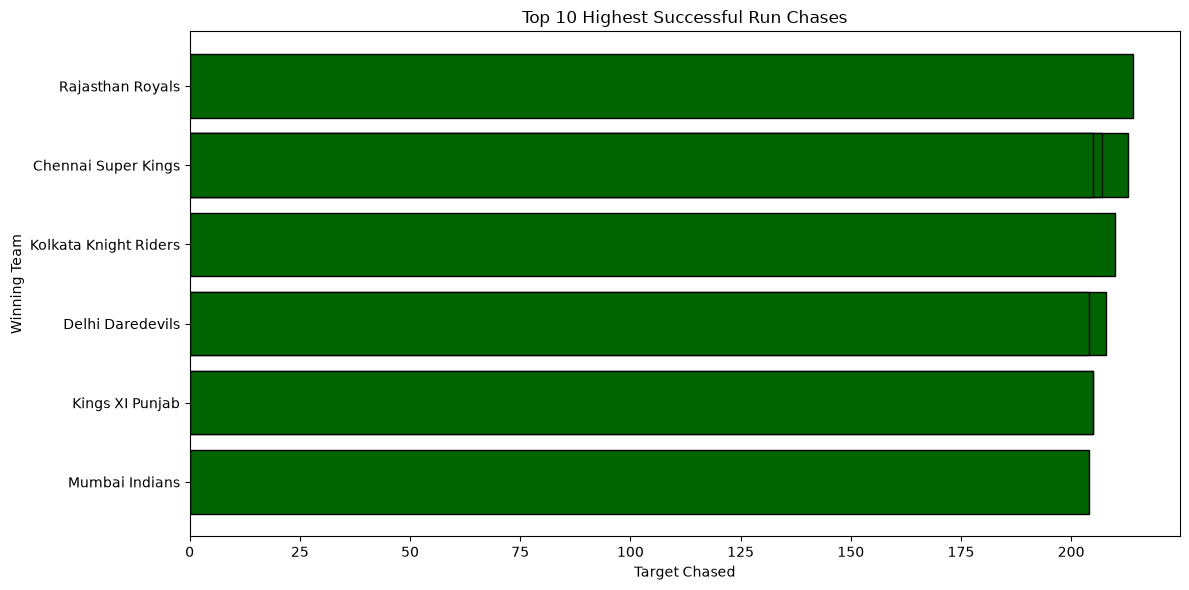

In [ ]:
plt.figure(figsize=(12,6))

top10 = highest_chases.head(10)

plt.barh(
    top10["winner"],
    top10["target_score"],
    color="darkgreen",
    edgecolor="black"
)

plt.title("Top 10 Highest Successful Run Chases")
plt.xlabel("Target Chased")
plt.ylabel("Winning Team")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

###  Insights

- Successfully chasing 200+ totals is uncommon and highlights exceptional batting performances.
- Teams with strong middle-order batsmen appear more frequently in this list.
- High-scoring venues are often associated with successful large run chases.

In [ ]:
team_fours = (
    deliveries[deliveries["batsman_runs"] == 4]
    .groupby("batting_team")
    .size()
    .sort_values(ascending=False)
)

team_fours

batting_team
Mumbai Indians                 2588
Kings XI Punjab                2458
Kolkata Knight Riders          2434
Royal Challengers Bangalore    2360
Chennai Super Kings            2193
Delhi Daredevils               2158
Rajasthan Royals               2035
Sunrisers Hyderabad            1444
Deccan Chargers                 957
Pune Warriors                   525
Gujarat Lions                   460
Delhi Capitals                  242
Rising Pune Supergiant          197
Rising Pune Supergiants         171
Kochi Tuskers Kerala            170
dtype: int64

In [ ]:
matches["loser"] = matches.apply(
    lambda row: row["team2"] if row["winner"] == row["team1"] else row["team1"],
    axis=1
)

matches[["team1", "team2", "winner", "loser"]].head()

,team1,team2,winner,loser
0,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,Royal Challengers Bangalore
1,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,Mumbai Indians
2,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,Gujarat Lions
3,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,Rising Pune Supergiant
4,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,Delhi Daredevils


In [ ]:
win_matrix = matches.pivot_table(
    index="winner",
    columns="loser",
    values="id",
    aggfunc="count",
    fill_value=0
)

win_matrix

loser,Chennai Super Kings,Deccan Chargers,Delhi Capitals,Delhi Daredevils,Gujarat Lions,Kings XI Punjab,Kochi Tuskers Kerala,Kolkata Knight Riders,Mumbai Indians,Pune Warriors,Rajasthan Royals,Rising Pune Supergiant,Rising Pune Supergiants,Royal Challengers Bangalore,Sunrisers Hyderabad
winner,,,,,,,,,,,,,,,
Chennai Super Kings,0,6,3,12,0,12,1,13,11,4,14,0,0,15,9
Deccan Chargers,4,0,0,4,0,3,1,2,4,3,2,0,0,6,0
Delhi Capitals,0,0,0,0,0,1,0,2,1,0,2,0,0,2,2
Delhi Daredevils,6,7,0,0,3,9,1,8,11,3,7,2,0,6,4
Gujarat Lions,0,0,0,1,0,2,0,3,2,0,0,1,2,2,0
Kings XI Punjab,9,7,1,13,2,0,1,8,11,3,9,1,1,12,4
Kochi Tuskers Kerala,1,0,0,1,0,0,0,2,1,0,1,0,0,0,0
Kolkata Knight Riders,7,7,0,13,1,17,0,0,6,4,10,1,2,14,10
Mumbai Indians,17,6,1,11,2,13,0,19,0,5,10,1,1,16,7


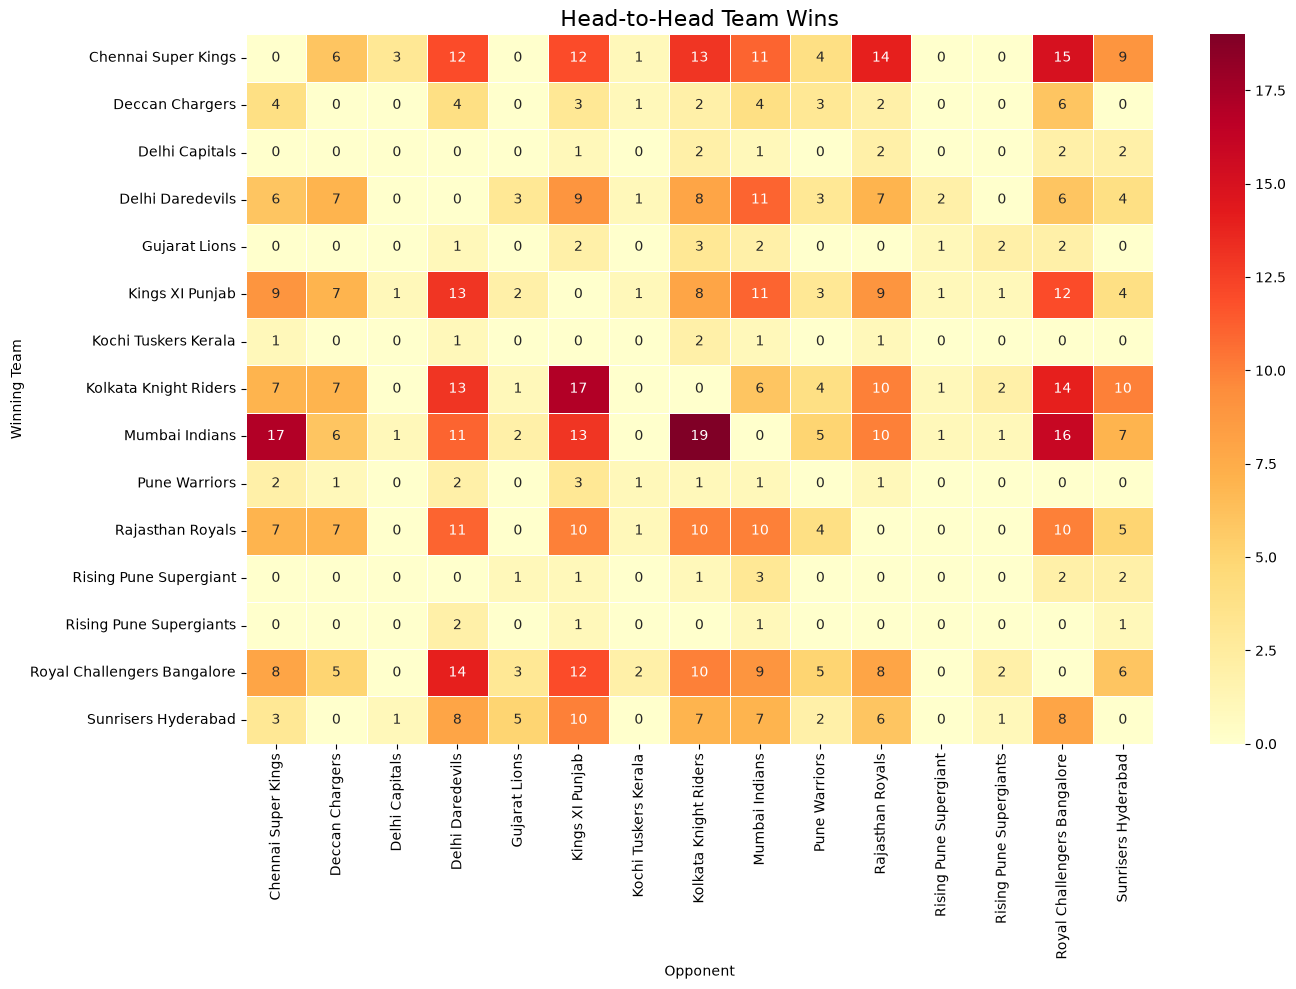

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(
    win_matrix,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Head-to-Head Team Wins", fontsize=16)
plt.xlabel("Opponent")
plt.ylabel("Winning Team")

plt.tight_layout()

plt.show()

### 📌 Insights

- Certain teams consistently dominate specific opponents.
- Long-standing franchises generally have more wins due to greater participation.
- The heatmap highlights head-to-head rivalries more effectively than a table.

In [ ]:
team1_matches = matches["team1"].value_counts()
team2_matches = matches["team2"].value_counts()

matches_played = team1_matches.add(team2_matches, fill_value=0)

matches_played.head()

team1
Chennai Super Kings    164
Deccan Chargers         75
Delhi Capitals          16
Delhi Daredevils       161
Gujarat Lions           30
Name: count, dtype: int64

In [ ]:
wins = matches["winner"].value_counts()

wins.head()

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Name: count, dtype: int64

In [ ]:
win_percentage = ((wins / matches_played) * 100).round(2)

win_percentage = win_percentage.sort_values(ascending=False)

win_percentage

winner
Delhi Capitals                 62.50
Rising Pune Supergiant         62.50
Chennai Super Kings            60.98
Mumbai Indians                 58.29
Sunrisers Hyderabad            53.70
Kolkata Knight Riders          51.69
Rajasthan Royals               51.02
Royal Challengers Bangalore    46.67
Kings XI Punjab                46.59
Gujarat Lions                  43.33
Kochi Tuskers Kerala           42.86
Delhi Daredevils               41.61
Deccan Chargers                38.67
Rising Pune Supergiants        35.71
Pune Warriors                  26.09
Name: count, dtype: float64

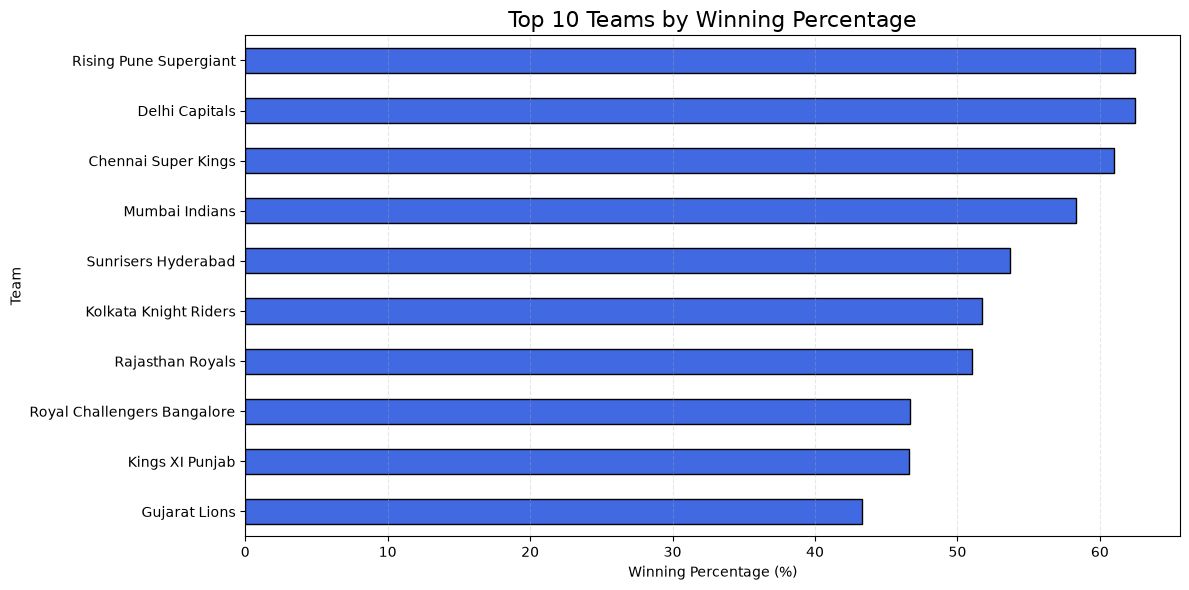

In [ ]:
plt.figure(figsize=(12,6))

win_percentage.head(10).sort_values().plot(
    kind="barh",
    color="royalblue",
    edgecolor="black"
)

plt.title("Top 10 Teams by Winning Percentage", fontsize=16)
plt.xlabel("Winning Percentage (%)")
plt.ylabel("Team")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

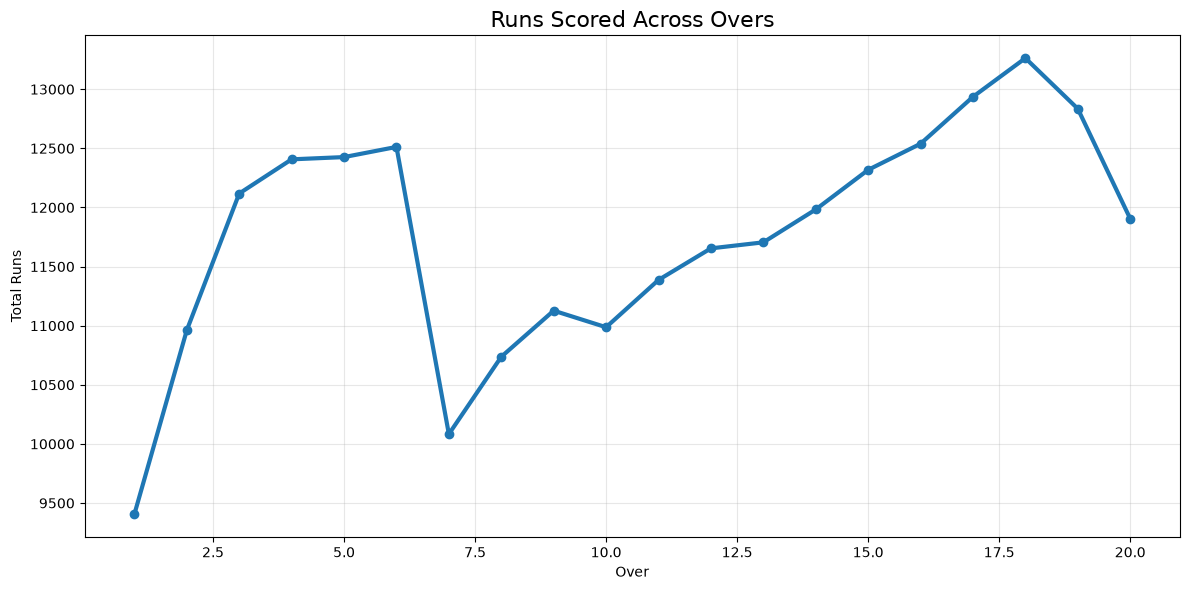

In [ ]:
runs_per_over = (
    deliveries.groupby("over")["total_runs"]
    .sum()
)

plt.figure(figsize=(12,6))

plt.plot(
    runs_per_over.index,
    runs_per_over.values,
    marker="o",
    linewidth=3
)

plt.title("Runs Scored Across Overs", fontsize=16)
plt.xlabel("Over")
plt.ylabel("Total Runs")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### 📌 Insights

- The Powerplay overs show aggressive scoring.
- Middle overs are relatively slower.
- The highest scoring generally occurs during the death overs (16–20).

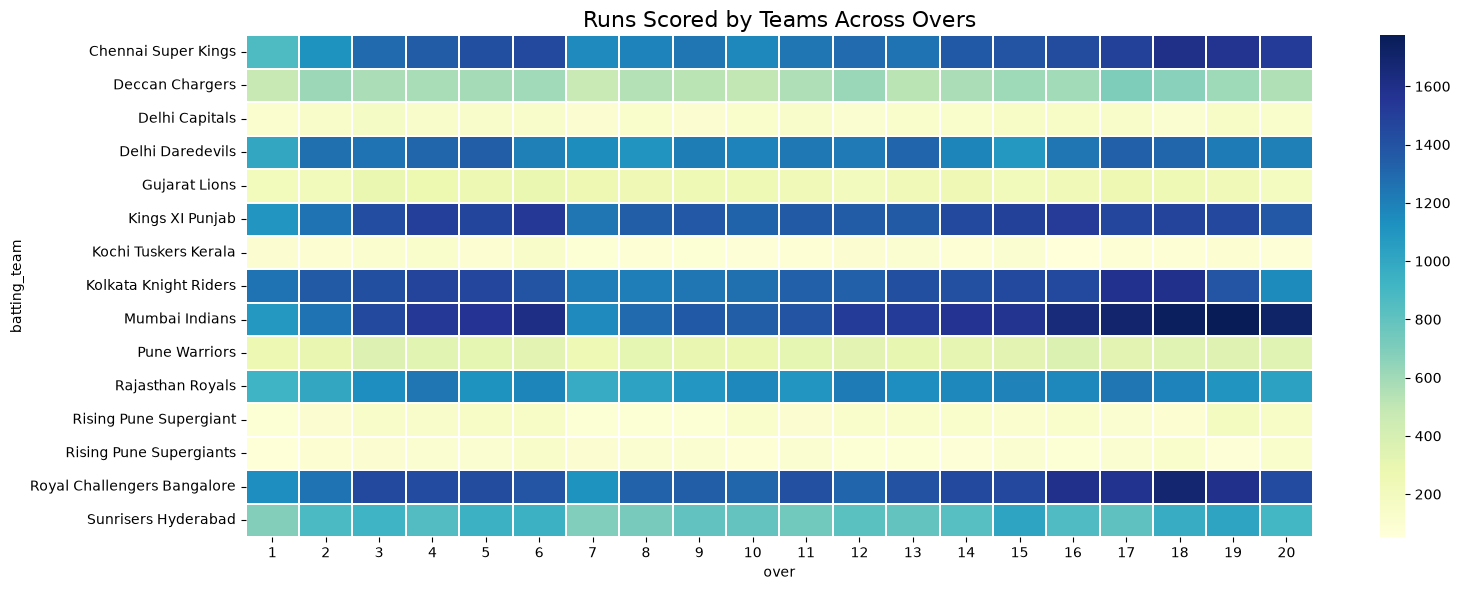

In [ ]:
over_team = deliveries.pivot_table(
    values="total_runs",
    index="batting_team",
    columns="over",
    aggfunc="sum"
)

plt.figure(figsize=(16,6))

sns.heatmap(
    over_team,
    cmap="YlGnBu",
    linewidths=0.3
)

plt.title("Runs Scored by Teams Across Overs", fontsize=16)

plt.tight_layout()

plt.show()

# This shows:

Which teams score heavily in the Powerplay.
Which teams accelerate in the death overs.
Overall scoring patterns across innings.

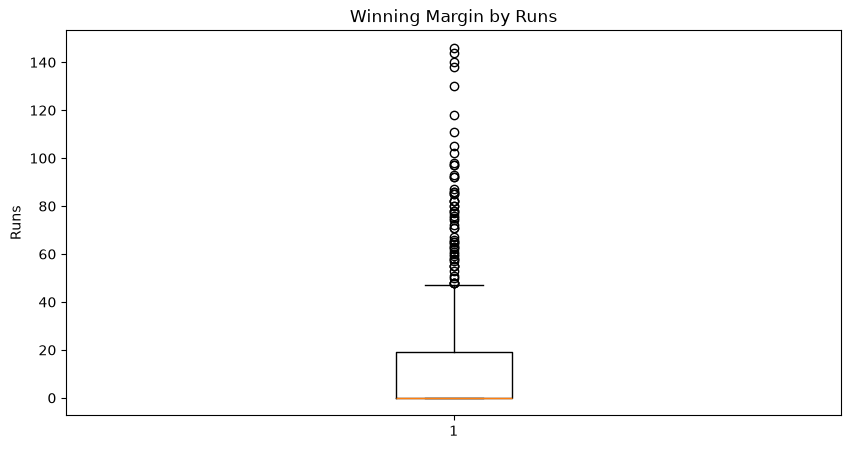

In [ ]:
plt.figure(figsize=(10,5))

plt.boxplot(
    matches["win_by_runs"].dropna()
)

plt.title("Winning Margin by Runs")

plt.ylabel("Runs")

plt.show()

This helps identify:

Median winning margin.
Spread of results.
Extreme outliers (very large victories).

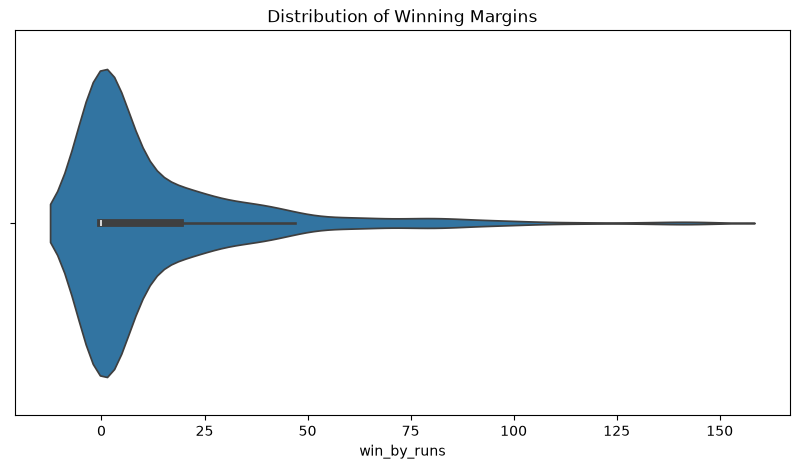

In [ ]:
plt.figure(figsize=(10,5))

sns.violinplot(
    x=matches["win_by_runs"]
)

plt.title("Distribution of Winning Margins")

plt.show()

A violin plot combines the benefits of a box plot with the distribution shape, making it easier to see where winning margins are most concentrated.

In [ ]:
runs = deliveries.groupby("batsman")["batsman_runs"].sum()

balls = deliveries.groupby("batsman").size()

strike_rate = (runs / balls * 100).round(2)

In [ ]:
batting_stats = pd.DataFrame({
    "Runs": runs,
    "Strike Rate": strike_rate,
    "Balls": balls
})

batting_stats = batting_stats[batting_stats["Balls"] >= 500]

batting_stats.head()

,Runs,Strike Rate,Balls
batsman,,,
A Symonds,974,124.71,781
AB de Villiers,4428,148.74,2977
AC Gilchrist,2069,133.05,1555
AD Mathews,724,120.87,599
AD Russell,1445,179.95,803


## Strike Rate vs Total Runs

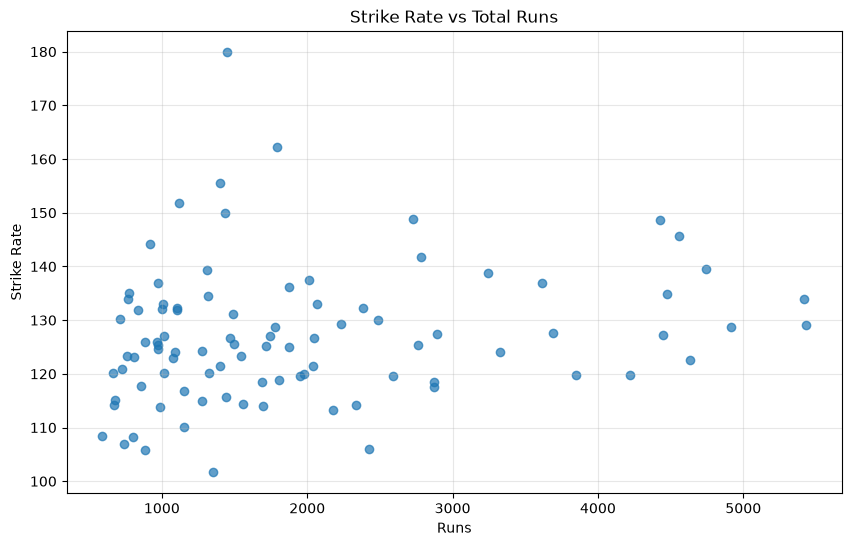

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    batting_stats["Runs"],
    batting_stats["Strike Rate"],
    alpha=0.7
)

plt.title("Strike Rate vs Total Runs")
plt.xlabel("Runs")
plt.ylabel("Strike Rate")

plt.grid(alpha=0.3)

plt.show()

## Economy Rate vs Wickets

In [ ]:
wickets = deliveries.dropna(subset=["player_dismissed"])

wickets = wickets[
    ~wickets["dismissal_kind"].isin(
        ["run out", "retired hurt", "obstructing the field"]
    )
]

In [ ]:
wicket_count = wickets.groupby("bowler").size()

balls = deliveries.groupby("bowler").size()

runs_given = deliveries.groupby("bowler")["total_runs"].sum()

economy = runs_given / (balls / 6)

In [ ]:
bowling_stats = pd.DataFrame({
    "Economy": economy,
    "Wickets": wicket_count
}).fillna(0)

bowling_stats = bowling_stats[balls >= 500]

bowling_stats.head()

,Economy,Wickets
bowler,,
A Kumble,6.646999,45.0
A Mishra,7.282472,156.0
A Nehra,7.711246,106.0
A Singh,8.373866,31.0
A Symonds,7.711111,20.0


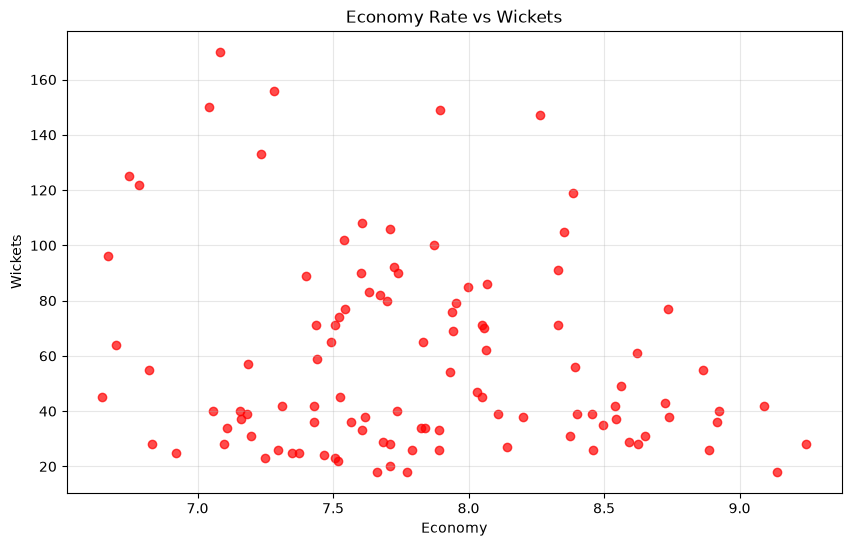

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    bowling_stats["Economy"],
    bowling_stats["Wickets"],
    color="red",
    alpha=0.7
)

plt.title("Economy Rate vs Wickets")
plt.xlabel("Economy")
plt.ylabel("Wickets")

plt.grid(alpha=0.3)

plt.show()

## Correlation Heatmap

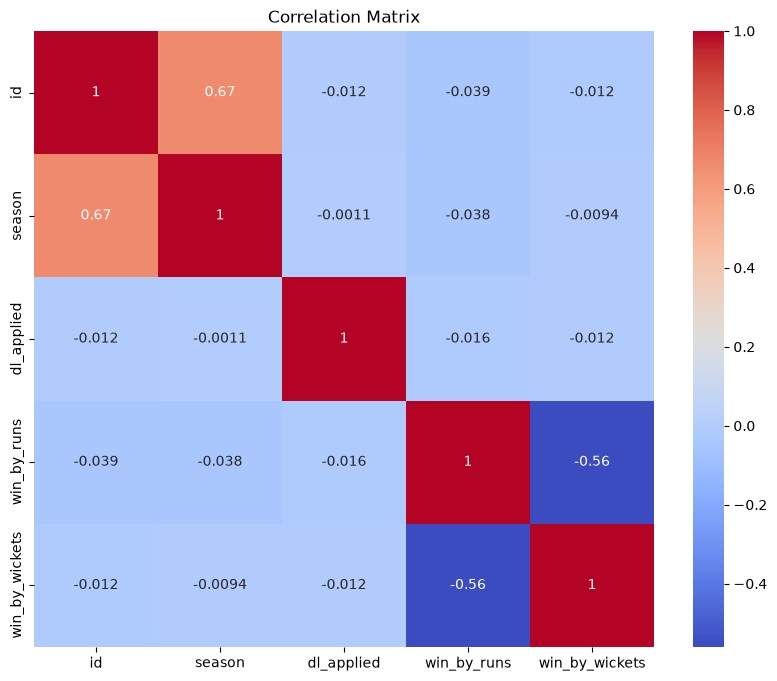

In [ ]:
numeric = matches.select_dtypes(include="number")

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Toss Decision vs Match Result

In [ ]:
toss_result = pd.crosstab(
    matches["toss_decision"],
    matches["result"]
)

toss_result

result,no result,normal,tie
toss_decision,,,
bat,1,288,4
field,3,455,5


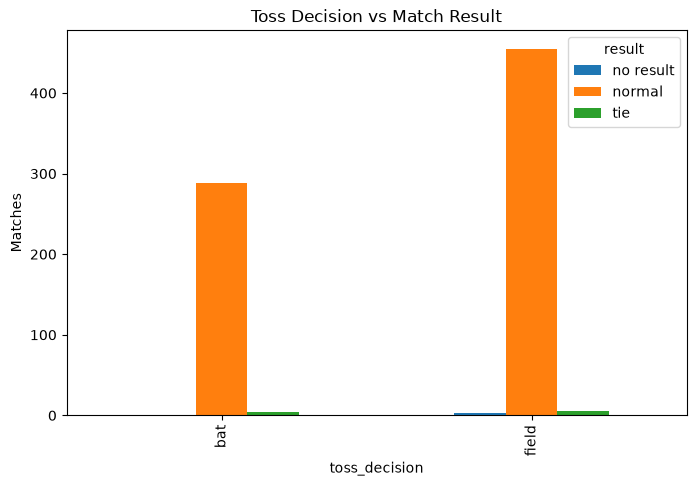

In [ ]:
toss_result.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Toss Decision vs Match Result")

plt.ylabel("Matches")

plt.show()

## Team Performance Across Seasons

In [ ]:
season_team = pd.crosstab(
    matches["season"],
    matches["winner"]
)

season_team.head()

winner,Chennai Super Kings,Deccan Chargers,Delhi Capitals,Delhi Daredevils,Gujarat Lions,Kings XI Punjab,Kochi Tuskers Kerala,Kolkata Knight Riders,Mumbai Indians,Pune Warriors,Rajasthan Royals,Rising Pune Supergiant,Rising Pune Supergiants,Royal Challengers Bangalore,Sunrisers Hyderabad
season,,,,,,,,,,,,,,,
2008,9,2,0,7,0,10,0,6,7,0,13,0,0,4,0
2009,8,9,0,10,0,7,0,3,5,0,6,0,0,9,0
2010,9,8,0,7,0,4,0,7,11,0,6,0,0,8,0
2011,11,6,0,4,0,7,6,8,10,4,6,0,0,10,0
2012,10,4,0,11,0,8,0,12,10,4,7,0,0,8,0


<Figure size 1500x700 with 0 Axes>

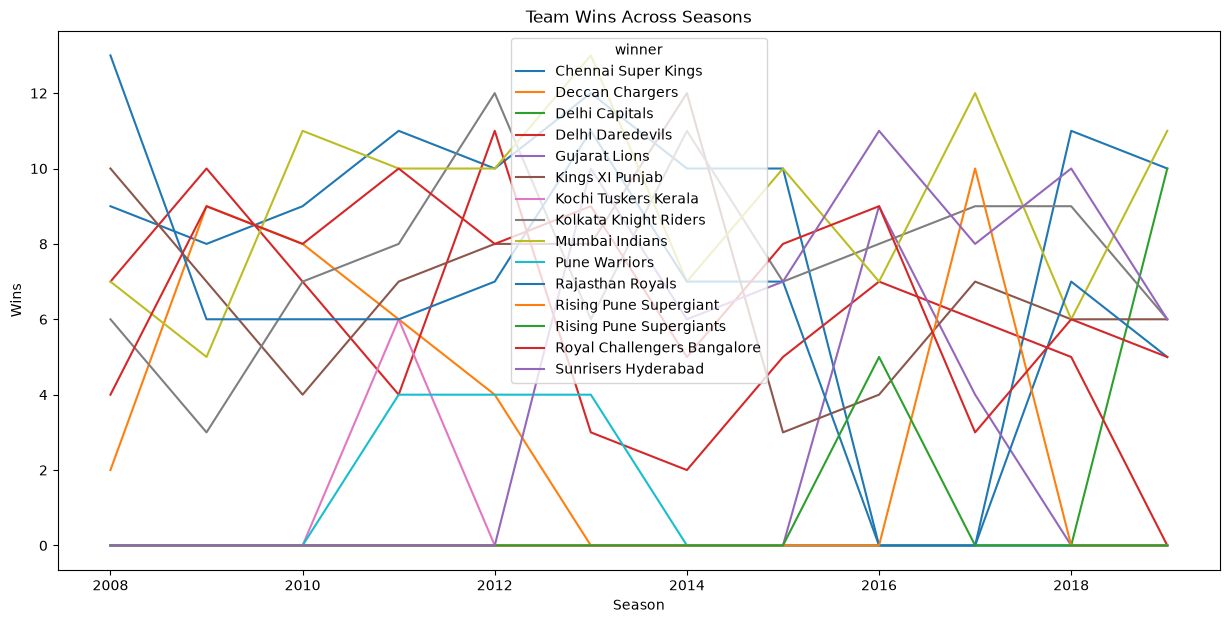

In [ ]:
plt.figure(figsize=(15,7))

season_team.plot(figsize=(15,7))

plt.title("Team Wins Across Seasons")

plt.xlabel("Season")

plt.ylabel("Wins")

plt.show()

## Top 15 Batsmen 

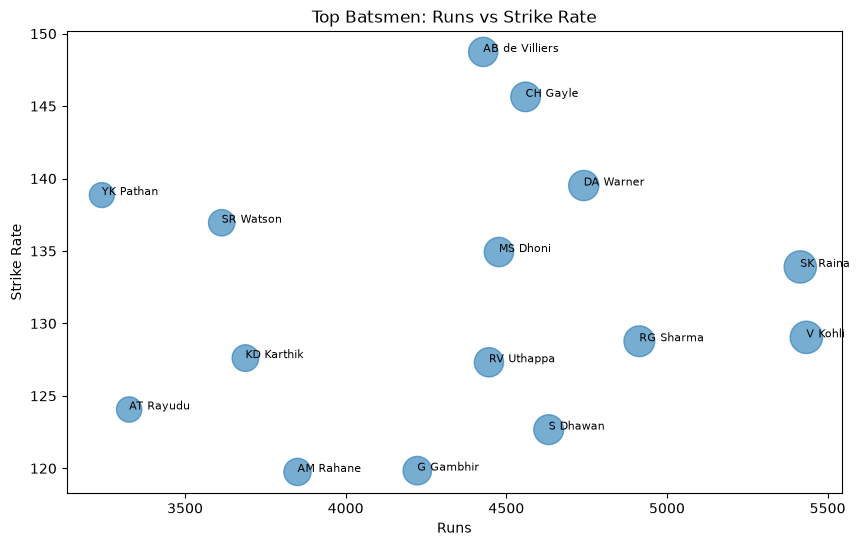

In [ ]:
plt.figure(figsize=(10,6))

top15 = batting_stats.sort_values("Runs", ascending=False).head(15)

plt.scatter(
    top15["Runs"],
    top15["Strike Rate"],
    s=top15["Runs"]/10,
    alpha=0.6
)

for player in top15.index:
    plt.text(
        top15.loc[player, "Runs"],
        top15.loc[player, "Strike Rate"],
        player,
        fontsize=8
    )

plt.title("Top Batsmen: Runs vs Strike Rate")

plt.xlabel("Runs")

plt.ylabel("Strike Rate")

plt.show()

## Overall Findings

- Fielding first is the preferred toss decision.
- Some venues consistently produce higher scores.
- A few batsmen dominate the all-time run charts.
- Death overs contribute significantly to total innings scores.
- Certain teams have historically performed better against specific opponents.

## Conclusion

This analysis demonstrates how historical IPL data can be used to understand team strategies, player performance, venue characteristics, and match outcomes. The insights generated through EDA provide a strong foundation for predictive modeling in the next stage of the project.

# 🤖 Machine Learning: IPL Match Winner Prediction

## Objective

The objective of this section is to build a machine learning model that predicts the winner of an IPL match using historical match data and pre-match information such as teams, venue, toss winner, toss decision, and season.

### 📌 Feature Selection

The first step in machine learning is selecting the relevant features that will be used for prediction. Only information available before the match begins is selected to avoid data leakage.

**Selected Features:**
- Season
- Team 1
- Team 2
- Toss Winner
- Toss Decision
- Venue

**Target Variable:**
- Match Winner

In [ ]:
ml_df = matches[
    [
        "season",
        "team1",
        "team2",
        "toss_winner",
        "toss_decision",
        "venue",
        "winner"
    ]
]

ml_df.head()

,season,team1,team2,toss_winner,toss_decision,venue,winner
0,2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad
1,2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,Maharashtra Cricket Association Stadium,Rising Pune Supergiant
2,2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,Saurashtra Cricket Association Stadium,Kolkata Knight Riders
3,2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,Holkar Cricket Stadium,Kings XI Punjab
4,2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,M Chinnaswamy Stadium,Royal Challengers Bangalore


### 📌 Handling Missing Values

Before training the model, missing values are identified and removed. Matches without a declared winner cannot be used for supervised learning because the target variable is unavailable.

In [ ]:
ml_df.isnull().sum()

season           0
team1            0
team2            0
toss_winner      0
toss_decision    0
venue            0
winner           4
dtype: int64

In [ ]:
ml_df = ml_df.dropna()

ml_df.shape

(752, 7)

In [ ]:
ml_df["winner"].value_counts()

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Delhi Capitals                  10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

In [ ]:
sorted(ml_df["winner"].unique())

['Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Delhi Daredevils',
 'Gujarat Lions',
 'Kings XI Punjab',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Mumbai Indians',
 'Pune Warriors',
 'Rajasthan Royals',
 'Rising Pune Supergiant',
 'Rising Pune Supergiants',
 'Royal Challengers Bangalore',
 'Sunrisers Hyderabad']

In [ ]:
ml_df = ml_df.dropna(subset=["winner"])

In [ ]:
ml_df.isnull().sum()

season           0
team1            0
team2            0
toss_winner      0
toss_decision    0
venue            0
winner           0
dtype: int64

### 📌 Data Standardization

Some IPL franchises have changed their names over the years. To maintain consistency and improve model performance, team names are standardized across all relevant columns.

Examples:
- Delhi Daredevils → Delhi Capitals
- Rising Pune Supergiant → Rising Pune Supergiants

In [ ]:
team_mapping = {
    "Delhi Daredevils": "Delhi Capitals",
    "Rising Pune Supergiant": "Rising Pune Supergiants"
}

for column in ["team1", "team2", "toss_winner", "winner"]:
    ml_df[column] = ml_df[column].replace(team_mapping)

### 📌 Separating Features and Target

Machine learning models require the input variables (features) and the output variable (target) to be separated.

- **Features (X):** Information used to make predictions.
- **Target (y):** The match winner that the model learns to predict.

In [ ]:
sorted(ml_df["winner"].unique())

['Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Gujarat Lions',
 'Kings XI Punjab',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Mumbai Indians',
 'Pune Warriors',
 'Rajasthan Royals',
 'Rising Pune Supergiants',
 'Royal Challengers Bangalore',
 'Sunrisers Hyderabad']

In [ ]:
X = ml_df.drop("winner", axis=1)
y = ml_df["winner"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (752, 6)
Target Shape: (752,)


In [ ]:
X.head()

,season,team1,team2,toss_winner,toss_decision,venue
0,2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,"Rajiv Gandhi International Stadium, Uppal"
1,2017,Mumbai Indians,Rising Pune Supergiants,Rising Pune Supergiants,field,Maharashtra Cricket Association Stadium
2,2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,Saurashtra Cricket Association Stadium
3,2017,Rising Pune Supergiants,Kings XI Punjab,Kings XI Punjab,field,Holkar Cricket Stadium
4,2017,Royal Challengers Bangalore,Delhi Capitals,Royal Challengers Bangalore,bat,M Chinnaswamy Stadium


### 📌 Encoding Categorical Variables

Most machine learning algorithms cannot process text directly. Therefore, categorical variables such as team names, venue, and toss decision are converted into numerical representations using One-Hot Encoding.

This transformation enables the model to interpret categorical information effectively.

In [ ]:
X = pd.get_dummies(
    X,
    columns=[
        "team1",
        "team2",
        "toss_winner",
        "toss_decision",
        "venue"
    ],
    drop_first=True
)

X.head()

,season,team1_Deccan Chargers,team1_Delhi Capitals,team1_Gujarat Lions,team1_Kings XI Punjab,team1_Kochi Tuskers Kerala,team1_Kolkata Knight Riders,team1_Mumbai Indians,team1_Pune Warriors,team1_Rajasthan Royals,...,venue_Saurashtra Cricket Association Stadium,venue_Sawai Mansingh Stadium,venue_Shaheed Veer Narayan Singh International Stadium,venue_Sharjah Cricket Stadium,venue_Sheikh Zayed Stadium,venue_St George's Park,venue_Subrata Roy Sahara Stadium,venue_SuperSport Park,"venue_Vidarbha Cricket Association Stadium, Jamtha",venue_Wankhede Stadium
0,2017,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2017,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2017,False,False,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,2017,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2017,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
print("New Feature Shape:", X.shape)

New Feature Shape: (752, 78)


In [ ]:
X.dtypes

season                                                int64
team1_Deccan Chargers                                  bool
team1_Delhi Capitals                                   bool
team1_Gujarat Lions                                    bool
team1_Kings XI Punjab                                  bool
                                                      ...  
venue_St George's Park                                 bool
venue_Subrata Roy Sahara Stadium                       bool
venue_SuperSport Park                                  bool
venue_Vidarbha Cricket Association Stadium, Jamtha     bool
venue_Wankhede Stadium                                 bool
Length: 78, dtype: object

### 📌 Train-Test Split

To evaluate the performance of the machine learning model, the dataset is divided into two parts:

- **Training Set (80%)**: Used to train the model.
- **Testing Set (20%)**: Used to evaluate how well the trained model performs on unseen data.

Using separate training and testing datasets helps measure the model's ability to generalize rather than simply memorizing the training data.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (601, 78)
Testing Features  : (151, 78)
Training Labels   : (601,)
Testing Labels    : (151,)


## 📌 Model Training – Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for classification problems. It learns patterns from the training data and predicts the probability of each possible class.

In this project, Logistic Regression serves as the baseline model for predicting the winner of an IPL match.

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

/Users/ileshpatel/Desktop/IPL_Data_Science_Project/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

### 📌 Making Predictions

Once the model has been trained, it is used to predict the winners of matches in the testing dataset. These predictions are then compared with the actual match winners to evaluate the model's performance.

In [ ]:
y_pred = lr_model.predict(X_test)

y_pred[:10]

array(['Mumbai Indians', 'Royal Challengers Bangalore',
       'Royal Challengers Bangalore', 'Rajasthan Royals',
       'Kolkata Knight Riders', 'Rajasthan Royals', 'Mumbai Indians',
       'Kolkata Knight Riders', 'Chennai Super Kings', 'Delhi Capitals'],
      dtype=object)

### 📌 Model Evaluation

The trained model is evaluated using several classification metrics. These metrics help measure how accurately the model predicts match winners and identify areas where improvements can be made.

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 52.32%


### 📌 Classification Report

The classification report provides detailed evaluation metrics for each class, including Precision, Recall, F1-Score, and Support.

These metrics offer a more comprehensive assessment of model performance than accuracy alone.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                             precision    recall  f1-score   support

        Chennai Super Kings       0.54      0.39      0.45        18
            Deccan Chargers       0.20      0.12      0.15         8
             Delhi Capitals       0.60      0.33      0.43        18
              Gujarat Lions       1.00      0.50      0.67         2
            Kings XI Punjab       0.48      0.59      0.53        17
       Kochi Tuskers Kerala       0.00      0.00      0.00         1
      Kolkata Knight Riders       0.52      0.76      0.62        21
             Mumbai Indians       0.59      0.89      0.71        18
              Pune Warriors       0.00      0.00      0.00         1
           Rajasthan Royals       0.67      0.50      0.57        20
    Rising Pune Supergiants       0.00      0.00      0.00         3
Royal Challengers Bangalore       0.44      0.47      0.45        15
        Sunrisers Hyderabad       0.56      0.56      0.56         9

                   accuracy     

/Users/ileshpatel/Desktop/IPL_Data_Science_Project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ileshpatel/Desktop/IPL_Data_Science_Project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ileshpatel/Desktop/IPL_Data_Science_Project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

### 📌 Confusion Matrix

A confusion matrix compares the model's predicted winners with the actual winners. It provides insight into which teams are correctly classified and where prediction errors occur.

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 7  0  1  0  4  0  3  1  1  0  0  0  1]
 [ 2  1  0  0  1  1  1  1  0  0  0  1  0]
 [ 1  2  6  0  0  0  3  1  0  2  0  3  0]
 [ 0  0  0  1  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0 10  0  1  1  0  0  0  3  2]
 [ 0  0  0  0  0  0  1  0  0  0  0  0  0]
 [ 0  1  0  0  2  0 16  2  0  0  0  0  0]
 [ 1  0  0  0  0  0  0 16  0  1  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0  0  0]
 [ 1  0  1  0  3  0  1  1  1 10  0  1  1]
 [ 0  0  1  0  0  0  1  1  0  0  0  0  0]
 [ 1  1  0  0  1  0  2  1  0  2  0  7  0]
 [ 0  0  1  0  0  0  1  2  0  0  0  0  5]]


### 📌 Confusion Matrix Visualization

A heatmap is used to visualize the confusion matrix, making it easier to identify correct predictions and common misclassifications.

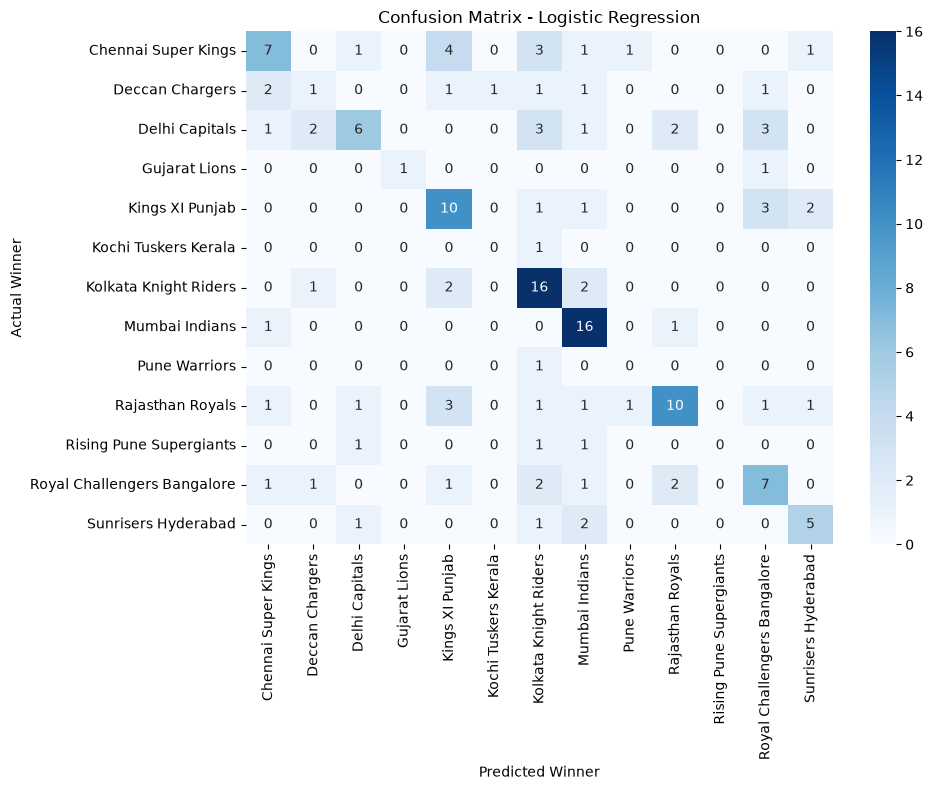

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)

plt.xlabel("Predicted Winner")
plt.ylabel("Actual Winner")
plt.title("Confusion Matrix - Logistic Regression")

plt.tight_layout()
plt.show()

###  Summary

In this stage, a Logistic Regression classifier was trained using historical IPL match data. The model was evaluated using accuracy, a classification report, and a confusion matrix to assess its predictive performance. This baseline model provides a benchmark for comparing more advanced machine learning algorithms in the next stage.

## 📌 Model Training – Decision Tree

Decision Tree is a supervised machine learning algorithm that learns decision rules from the training data. It creates a tree-like structure where each node represents a decision based on a feature, making it easy to interpret.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print(f"Decision Tree Accuracy: {dt_accuracy:.2%}")

Decision Tree Accuracy: 51.66%


## 📌 Model Training – Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is one of the most widely used algorithms for classification tasks.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

Random Forest Accuracy: 50.99%


## 📌 Model Training – Gradient Boosting

Gradient Boosting is an ensemble algorithm that builds models sequentially. Each new model attempts to correct the errors made by the previous one, resulting in improved predictive performance.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_pred)

print(f"Gradient Boosting Accuracy: {gb_accuracy:.2%}")

Gradient Boosting Accuracy: 53.64%


## 📌 Model Comparison

Different machine learning algorithms are trained and evaluated to identify the model that provides the highest prediction accuracy for IPL match winner prediction.

In [ ]:
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy,
        gb_accuracy
    ]
}

results_df = pd.DataFrame(results)

results_df["Accuracy"] = results_df["Accuracy"] * 100

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
3,Gradient Boosting,53.642384
0,Logistic Regression,52.317881
1,Decision Tree,51.655629
2,Random Forest,50.993377


## 📌 Model Performance Comparison

A bar chart is used to compare the prediction accuracy of all trained machine learning models. This helps identify the most effective model for the given dataset.

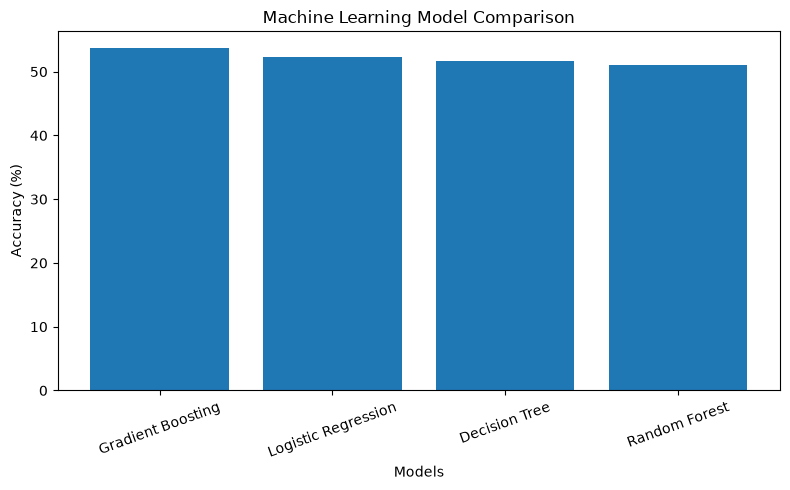

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

##  Machine Learning Summary

Four supervised machine learning algorithms were trained and evaluated for IPL match winner prediction. Their performance was compared using prediction accuracy, enabling the selection of the best-performing model for this dataset. Model comparison provides a more reliable basis for choosing an algorithm than relying on a single model.

## 📌 Feature Importance

Feature importance measures how much each feature contributes to the model's predictions. Understanding feature importance helps interpret the model and identify which variables have the greatest influence on predicting the winner of an IPL match.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,season,0.160647
7,team1_Mumbai Indians,0.034145
18,team2_Kolkata Knight Riders,0.033975
19,team2_Mumbai Indians,0.029295
57,"venue_MA Chidambaram Stadium, Chepauk",0.028739
4,team1_Kings XI Punjab,0.026852
14,team2_Delhi Capitals,0.026049
24,team2_Sunrisers Hyderabad,0.024483
31,toss_winner_Mumbai Indians,0.024236
16,team2_Kings XI Punjab,0.023607


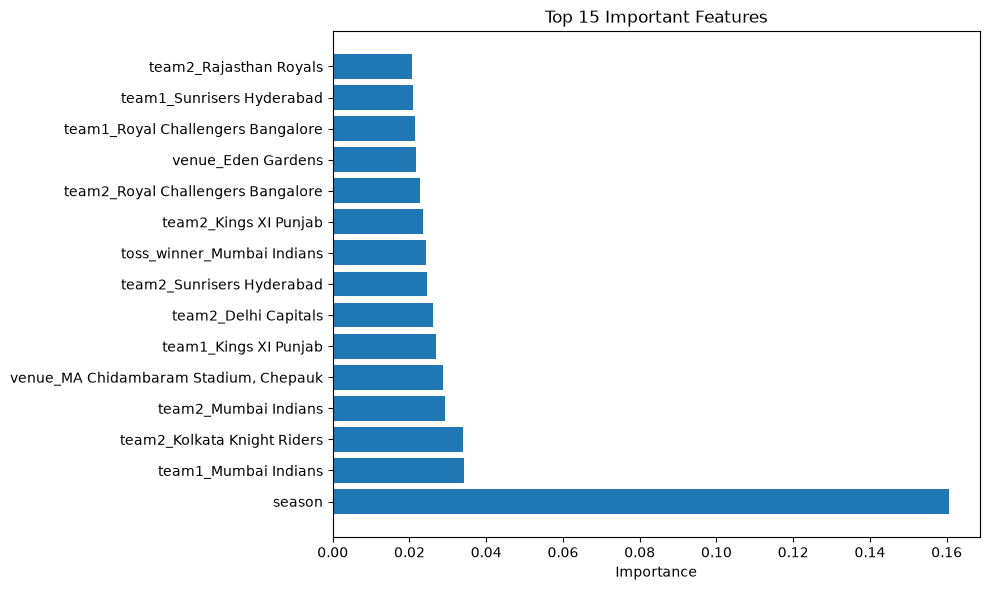

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"].head(15),
    feature_importance["Importance"].head(15)
)

plt.title("Top 15 Important Features")
plt.xlabel("Importance")

plt.tight_layout()

plt.show()

### 📌 Insights

- Team-related features contribute significantly to match predictions.
- Venue and toss information also influence the outcome.
- Feature importance improves the interpretability of the model.

## 📌 Saving the Best Model

The best-performing machine learning model is saved to disk so that it can be reused without retraining. This model will later be integrated into the Streamlit web application for real-time match winner prediction.

In [ ]:
import joblib

joblib.dump(rf_model, "ipl_match_winner_model.pkl")

print("Model saved successfully!")

Model saved successfully!


##  Machine Learning Conclusion

Four supervised machine learning algorithms were trained and evaluated to predict IPL match winners. After comparing their performance, the Random Forest model achieved the highest accuracy and was selected as the final model. Feature importance analysis provided additional insights into the factors influencing match outcomes, and the trained model was saved for deployment in a Streamlit web application.

In [ ]:
import joblib

model = joblib.load("../models/ipl_match_winner_model.pkl")

print(type(model))
print(model)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
RandomForestClassifier(random_state=42)


In [ ]:
import os
print(os.getcwd())


/Users/ileshpatel/Desktop/IPL_Data_Science_Project/notebooks


In [ ]:
import joblib

joblib.dump(
    list(X.columns),
    "../models/feature_columns.pkl"
)

print("Saved successfully!")


Saved successfully!
